In [58]:
# v4 240909 Adding a variable rate breaking of free chains
# v5 240909 Added consolidated array by weight, and two graphs based on it
# v6 240909 Updating rates for attaching and detaching Ts on complexes
# Note: the model stopped running with these new rates so needs to be fixed
# cntd. Continued tuning of parameters, number format (Float64), algorithm inherent accuracy etc to try to make the model produce any results again
# Could be that with the new rates (assuming they are more accurate) made the model more sensitive, and perhaps it will take much longer to run going forward
# v7 Saving a copy that at least is running, and largely with rates suggested by chatGPT (confirmed working up to 5 days, but shopuld be longer, just a bit slow)
# v8 Added possibility to load data but not running simulation
# v9 Just saving another copy with a seemingly working version after many changes
# v10 Moving on with discretizing the zero to one step to make it even clearer when the pårocess actually starts
# v11 Saving the seemingly working version with naive solver (still to try: discretize, which was the reason to build the naive solver)
# v12 Now running naive and discretized with real and natural rates
# v13 Saving a fully working version with realistic rates and discretized development, in this version we can see life forming (and sometime several time before growth starts) and each step on the way has its own attempts and eventual birth
# v14 Strating to build the L,D version by adding data structure for a base substrate from which the L and D versions are created respectively, and having two sets of concerentrations separately for the L and the D side. and the updating the reaction_dynamics function
# v15 Need to add a dynamic time step, something that I completely ignored in my first version of the naive
# v16 After many changes in 15, trying to remove some debug stuff and make a clean running model
# v17 Continued fixing and nearing the new working model
# v18 240925 In this version I intend to implement a statistical model for the two nucleotide case
# v18 See comment below
# v18 241002 Restarting fresh after having no success in running the new version, should be able to port most of it over though so trying that now
# v19 Need to change some of the basic structure so that extend and explore can work together with a variable time step (and in general one bigger than 1)
# v19b Breaking out a new branch after som success in making the first step run with same result as before
# v19c Comment: this seems to work for concentration, but extend/explore not yet handled. Saving a version (241003) and continuing in a new version
# Note: started to put structures in place to switch into classes to handle reaction dynamics and concentrations, next step will complete that work and only after that get back to extend/explore
# v20 Continuing to implement classes for reaction dynamics and concentrations (aim is to make code more flexible and to get to a point when it is easy to overview and when I can implement extend/explore without much effort)
# Note 241007: Seems to work pretty well now, saving a version and continue in v21
# v21 After introducing a completely new structure, now back to add in the explore part that was added just before classes and that is not yet built into this version
# Note: This now runs and a file was saved, moving on to v22 just to make sure a running version is available
# v22 Not sure what to do next. One idea was to make a true exploration vector with a stitistical model for how each permutation is actually explored, with number of moleules per permutation
# v23 First serious attempt for a complete deterministic exploration model
# Not: Har tagit denna till en version som faktiskt kör utan fel, fortsätter i v24
# v24 Take v23 to a fully running version
# Note: Saving this as a working copy of v24, and it seems to run pretty well, although there may still be issues lurking
# v25 As v24 was working really well this is an attempt to tidy things up by removing extra cells and print statements etc
# v26 Will try to fix the catalyzed polymerization so that it does not slow down the model so much, I believe the high values reduced the time step
# v27 Note: This is one of the runs from v26 where I found the solutions deviated and I wanted to continue running, to do this I added a model class, a save function and a continue solve
# v28 Cleaning up a bit and trying some rusn to see if it works. Specifically curious to why the L vs D does not seem to be unstable
# Note: In this version v28 save and load were modified and confirmed working using pickle, saving partial results was also madded
# Note2: Seems this works in a way, but next step has to be proper competition between L and D catalysing effects. Right now the become the same as soon as concentration of the catalyzing free chain is high enough between L and D
# In v29 I will address this
# 29 Maybe this is the first model that will properly display the instability of the system. As soon as catalysing effects appear one side may take over. Let's see!
# v30 Last version seems to have made an important change, with more clearly deviating concentration curves. In this version aiming to add at öeast rudimentory break down of chains so that eventually the losing side can vanish entirely

# This is a copy where I try to run model_size = 6
# It takes a lot of time so not sure if something is wring, extending the run in bits and maybe it get to size = 6 eventually
# Several long runs with modofied k rates perfoemed, see notes and save file names towards the bottom of the notebook

# And this is a copy after realizinng that increasing k_form has made nucleotodes being caugt up in complexes
# That leads to a decreased templated polymerization downstream and largely stops the process.
# Will keep the original running to see what happens, but here will try to speed things up
# Attempt 1 will be to introduce separate k for complex_same and complex_inactive and reduce k_form_same back to what k_form was originally

# Note: Two things that need further development:
# 1. A better handling of the sub-to-nucleotide dynamics when the system is dominated by catalysing agets. Basically handle this separately and decide step length without taking substrate into account, all substrate will be converted anyway
# 2. Ability to expand the model by increasing size, essentially a method in all classes that extends the lists containing arrays
# 3. There was some last issue with loading a model and continue to run. I had to set model.y_final = model.y_result.get_last_values() after loading, need to figure out why this didn't work in the model.load() method 

# V31 Atting sepaate k for complex same, and fixing an error in system dev where complex_same was not dissociated leading to a lockup after templeted polymerization that slowed the process down
# This: is a copy running the model from start with the new fizes and with thenew k
# A copy of the copy further tweaking the k rates to try to make the model progress beyond size 5, right now it reaches an equilibrium at 5 and has a hard time getting to 6

# v32 Trying to make necessary changes and fixes to make the model run with a minimum set of k rates. Initially this fails because the t step becomes very small, error searching
# Note: found an error in system_dev that was applying an incorrect change to one of the free vectors, it caused a big negative change and a very small time step

# v33 Automatic extension of model one largest chain reaches over a specified level of concentration
# This copy is only used for printing saved versions

# v34 with some work transferred over from the first v34 version, relating to a better model for when the system is saturated with catalysing agents
# v35 Had to rethink the production of nucletides from substrate, will try the new version in this file
# Note: in the new version an equilibrium equation is setup for all the dynamics of substrate, including dorming and dissociation of nuclotides as well as catalysed forming of the same

# v36 was the attempt (failed) with parallelizing (NJIT and JOBLIB)
# v37 will take a different approach to performance: save much less data about the system in each step, in reality we only need the weight by size and the catalyser concentrations

# v38 My changes in v37 worked overall but I need to change a little bit how the classes are setup, and this is an attempt to have a better and clearer process entirely based on p. So one must setup a p first to make any channges to for example size, same with k
# v39 Overall the changes in v38 were ok, but ran into multiple issues with all the different concentration models user everywhere, and th ps and ks that were updated and didm't aligt
# v39 cntd. Will try to make things more clear and then to be able to run, save, load and continue run safely
# v40 Adding cat trail and moving plot to conc class, now using class method for printing inside col solver

# v42 Just saving a copy of the working version with the new cat trail and the plot moved to conc class
# Note: restarting the run size 8 from the last couple of days, just using this version as a base for better plots

# v44 Adding sequence diversity tracking (seq_count per length per stereo model L/D) and feedback plots at save points
version = "v44"


In [59]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from datetime import datetime
import time
import pickle
import random
import warnings
import random
import os
import copy
from concurrent.futures import ThreadPoolExecutor

# Persistent thread pool — created once and reused every time step to minimise overhead.
# Pool size covers: 2 for L/D parallelism + up to (auto_extend_to - 1) for chain-length loop.
_PARALLEL_SIZE_THRESHOLD = 5          # use parallel chain-length loop only when size > this
_POOL = ThreadPoolExecutor(max_workers=os.cpu_count() or 8)


In [60]:
class ModelControlParameters:
    def __init__(self, 
                 size,
                 output_steps           = 1000,
                 max_time_step_change   = 0.75,
                 max_time_step          = 500,
                 model_max_t            = 10 * 24 * 3600,
                 discretize_development = True,
                 reduced_save_state     = True,
                 cross_inhibit          = True,
                 limit_pairing          = True,
                 verbose_error          = False,
                 load_file              = False,
                 save_file              = False,
                 save_progress          = True,
                 run_simple_simulation  = True,
                 load_file_name         = None,
                 auto_extend            = True,
                 auto_extend_at         = 1e-20,
                 auto_extend_to         = 12
                ):
        
        # Size of the model (max chain length modeled) and minimum hairpin formation
        self.size = size
        
        # Size of output arrays
        self.output_steps = output_steps
        
        # Control model time steps and scope
        self.max_time_step_change = max_time_step_change
        self.max_time_step = max_time_step
        self.model_max_t = model_max_t
        
        # Environment controls
        self.discretize_development = discretize_development
        self.reduced_save_state = reduced_save_state
        self.cross_inhibit = cross_inhibit
        self.limit_pairing = limit_pairing
        
        # Screen output control
        self.verbose_error = verbose_error
        
        # File handling controls
        self.load_file = load_file
        self.save_file = save_file
        self.save_progress = save_progress
        self.run_simple_simulation = run_simple_simulation
        self.load_file_name = load_file_name if load_file_name is not None else f"save_file_size_{size}_20240910_204206.txt"
        
        # Auto extend
        self.auto_extend = auto_extend
        self.auto_extend_at = auto_extend_at
        self.auto_extend_to = auto_extend_to


    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def printme(self):
        for name, value in vars(self).items():
            print(name, " = ", value)

            
            

In [61]:
### STARTING TO COLLECT THE IDEAS INTO A STRUCTURE
# Support functions

# This will be used in the cofre model at a later stage (leave it here for now)

def  discretize(var):
    rnd = np.random.rand(*var.shape)
    #print("rnd: ", rnd)

    # Extract the integer part
    var_int_part = np.floor(var)

    # And then the fractional part
    var_frac_part = var - var_int_part
    var_frac_part[rnd < var_frac_part] = 1.0
    var_frac_part[var_frac_part != 1] = 0.0

    return var_int_part + var_frac_part


# This is used to make sure we can handle the 3-5 end in an easy way
# The function just returns the integer corresponding to the reversed bit order
# Bit size is needed to make sure we fill zeros properly after reversion the order

def reverse_bits_numpy(n, bit_size):
    # Convert the number to a binary string, remove the '0b' prefix, and pad to the bit size
    bin_str = np.binary_repr(n, bit_size)
    # Reverse the binary string
    reversed_bin_str = bin_str[::-1]
    # Convert the reversed binary string back to an integer
    return int(reversed_bin_str, 2)

# The matching exact complement to a bit pattern
# This function first reverses bit order and the takes an XOR to find the complement
def matching_complement(n, bit_size):
    reversed_n = reverse_bits_numpy(n, bit_size)
    complement = reversed_n ^ (np.power(2, bit_size) - 1)
    return complement

# Produce the square complement matrix for a mode
def complex_matrix(bit_size):
    format_bit = "0"+str(bit_size)+"b"
    permutations = np.power(2, bit_size)
    matrix = np.zeros((permutations, permutations))
    for i in range(permutations):
        complement = matching_complement(i, bit_size)
        matrix[i, complement] = 1
        
    return matrix

# Produce the mixed complement matrix for a mode (between the mode and one size up)
def complex_matrix_1up(bit_size):
    bit_size_1 = bit_size
    bit_size_2 = bit_size + 1
    format_bit_1 = "0"+str(bit_size_1)+"b"
    format_bit_2 = "0"+str(bit_size_2)+"b"
    permutations_1 = np.power(2, bit_size_1)
    permutations_2 = np.power(2, bit_size_2)
    matrix = np.zeros((permutations_1, permutations_2))
    for i in range(permutations_1):
        complement_1 = matching_complement(2 * i    , bit_size_2)
        complement_2 = matching_complement(2 * i + 1, bit_size_2)
        matrix[i, complement_1] = 1
        matrix[i, complement_2] = 1
        
    return matrix

# This function can take two concentration arrays and extend one (base) by the other (extension)
# The output will be the concentration array for the resulting longer chain
# Usage: dydt_concentration_size_(m+n) = k_extend * extend(base, extension)
# Where base is of size m and extension of size n
# Special case (and most omportant) will be extension by one

def spontaneous_polymerization_matrix(base, extension):
    base_size = np.size(base)
    ext_size = np.size(extension)
    poly_matrix = np.matmul(np.reshape(extension,(ext_size,1)), np.reshape(base,(1,base_size)))
    return poly_matrix

def extend(poly_matrix):
    base_size = np.size(poly_matrix[:,0])
    ext_size = np.size(poly_matrix[0,:])
    extended = np.reshape(poly_matrix, (1,base_size*ext_size),order = 'F')
    return extended

# This function calculates the production rate of complexes between chains with a size difference of 1
# The optional rate parameter k can be a scalar or a matrix (m x n, where m = short length and n = longer length)
def complex_form_iup(longer_strand, shorter_strand, k = 1):
    # Note: extend is one smaller
    longer_size = np.size(longer_strand)
    shorter_size = np.size(shorter_strand)
    
    longer_bit_size = int(np.log2(longer_size))
    shorter_bit_size = int(np.log2(shorter_size))
    
    complex_form_matrix = complex_matrix_1up(shorter_bit_size)
    complex_form_1up = k * complex_form_matrix * np.matmul(np.reshape(shorter_strand,(shorter_size,1)),np.reshape(longer_strand,(1,longer_size)))
    
    return complex_form_1up

# This function calculates the production rate of complexes between chains with a size difference of 1
# The optional rate parameter k can be a scalar or a matrix (m x n, where m = short length and n = longer length)
def complex_form_same(strand_1, strand_2, k = 1):
    # Note: extend is one smaller
    strand_size = np.size(strand_1)
    
    bit_size = int(np.log2(strand_size))
    
    complex_form_matrix = complex_matrix(bit_size)
    complex_form_same = k * complex_form_matrix * np.matmul(np.reshape(strand_2,(strand_size,1)),np.reshape(strand_1,(1,strand_size)))
    
    return complex_form_same

def count_same_bits_with_mask(val1, val2, mask):
    # Apply the mask to both values
    masked_val1 = val1 & mask
    masked_val2 = val2 & mask
    
    # XOR the masked values to find differing bits
    differing_bits = masked_val1 ^ masked_val2
    
    # Count the number of identical bits (which will be 0 in the XOR result)
    # We use bitwise negation (~differing_bits) & mask to ignore non-masked bits in the count.
    same_bits = bin(~differing_bits & mask).count('1')
    
    return same_bits

# Example usage
val1 = 0b11010110  # Example value 1
val2 = 0b11100110  # Example value 2
mask = 0b11110000  # Only compare the upper 4 bits

result = count_same_bits_with_mask(val1, val2, mask)
print(f"Number of matching bits: {result}")

def hairpin_form_self(bit_size, loop_size):
    max_stem = int(np.floor((bit_size - loop_size) / 2))
    max_stem_mask = np.power(2, max_stem) - 1
    permutations = np.power(2, bit_size)
    hairpin_form = np.zeros(permutations)
    hairpin_form_strength = np.zeros(permutations)
    for m in range(permutations):
        n = matching_complement(m, bit_size)
        for l in range(max_stem):
            stem_mask = np.power(2, l+1) - 1
            k = count_same_bits_with_mask(m, n, stem_mask)
            if k == l+1:
                hairpin_form[m]          = 1
                hairpin_form_strength[m] = k
            #print("compll: ", m, n, hairpin_form[m])
            #print(f'm: {m:0{bit_size}b}, n: {n:0{bit_size}b}, count: {hairpin_form[m]}, mask: {stem_mask}')
                            
    return hairpin_form, hairpin_form_strength
                            


Number of matching bits: 2


In [62]:
# Other support functions
def print_time(time = datetime.now()):
    time_str = current_time = datetime.now().strftime('%Y%m%d_%H%M%S')
    print("Time. ", time_str)

In [63]:
class ReactionConstants():
    def __init__(self, 
                 p,
                 volume            = 1.0,
                 NA                = 6.0221408e+23,
                 equilibrium_sub   = 1e-7,
                 k_eq_sub          = 1e-3,
                 k_t_form          = 1e-5,
                 k_t_diss          = 1e-7,
                 k_form            = 1e4,
                 k_diss            = 1e-2,
                 k_form_same       = 1e4,
                 k_diss_same       = 1e-2,
                 k_diss_a          = 0.7,
                 k_attach          = 1e4,
                 k_detach          = 1e-1,
                 k_poly            = 1e-2,
                 k_spont           = 1e-4,
                 k0_hpf            = 1e-3,
                 k_hpf_a           = 0.1, 
                 k_hpd_a           = 1.0,
                 k0_hpd            = 1e-2,
                 k0_break          = 1e-5,
                 hairpin_loop_size = 0,
                 catalytic_hairpin = 1,
                 k_hairpin_cat     = 0,
                 catalytic_free    = 0,
                 k_free_cat        = 1e7, # According to chatty between 1e4 and 1e7 roughly
                 max_cat_sub_use   = 1.0,
                 error_rate        = 0.01
                ):
        
        #self.size = size
        self.p = p.copy()
        
        # Natural substrate concentration and production rate
        self.equilibrium_sub = equilibrium_sub
        self.k_eq_sub = k_eq_sub
        
        # Reaction rate constants
        self.k_t_form      = k_t_form
        self.k_t_diss      = k_t_diss
        self.k_form_same   = k_form_same
        self.k_diss_same   = k_diss_same
        self.k_form        = k_form
        self.k_diss        = k_diss
        self.k_diss_a      = k_diss_a
        self.k_attach      = k_attach
        self.k_detach      = k_detach
        self.k_poly        = k_poly
        self.k_spont       = k_spont
        
        # Hairpin-related constants
        self.k0_hpf            = k0_hpf
        self.k0_hpd            = k0_hpd
        self.k_hpf_a           = k_hpf_a
        self.k_hpd_a           = k_hpd_a
        self.hairpin_loop_size = hairpin_loop_size
        
        # Chain breaking and hairpin catalysis constants
        self.k0_break          = k0_break
        self.k_hairpin_cat     = k_hairpin_cat
        self.catalytic_hairpin = catalytic_hairpin
        self.catalytic_free    = catalytic_free
        self.k_free_cat        = k_free_cat
        self.max_cat_sub_use   = max_cat_sub_use
        
        # Error rate
        self.error_rate = error_rate
        
        # Physical environment
        self.volume = volume
        self.NA = NA
        
        self.k_hairpin_form    = one_dim_storage(self.p.size)
        self.k_hairpin_dissolv = one_dim_storage(self.p.size)

        for i in range(self.p.size):
            hairpin_form, hair_pin_stem_strength = hairpin_form_self(bit_size = i+1, loop_size=self.hairpin_loop_size)
            self.k_hairpin_form[i]    = hairpin_form * k0_hpf * np.exp(- hair_pin_stem_strength * k_hpf_a) # The chain length uses number of nucleotides
            self.k_hairpin_dissolv[i] = k0_hpd * np.exp(- hair_pin_stem_strength * k_hpd_a) # The chain length dep uses number of base pairs in stem

    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def extend(self):
        self.p.size += 1
        self.k_hairpin_form    = one_dim_extend(self.k_hairpin_form)
        self.k_hairpin_dissolv = one_dim_extend(self.k_hairpin_dissolv)

        hairpin_form, hair_pin_stem_strength = hairpin_form_self(bit_size = self.p.size, loop_size = self.hairpin_loop_size)
        self.k_hairpin_form[self.p.size-1]    = hairpin_form * self.k0_hpf * np.exp(- hair_pin_stem_strength * self.k_hpf_a) # The chain length uses number of nucleotides
        self.k_hairpin_dissolv[self.p.size-1] = self.k0_hpd * np.exp(- hair_pin_stem_strength * self.k_hpd_a) # The chain length dep uses number of base pairs in stem
            
    def printme(self):
        for name, value in vars(self).items():
            print(name, " = ", value)




In [64]:
# Functions to create storage structures, mainly for concentrations
def one_dim_storage(size, add_time_dim = False):
    storage = []  # Use list instead of tuple
    for i in range(size):
        n = i + 1
        p = 2 ** n
        if add_time_dim:
            storage.append(np.zeros(( p, 1)))  # Append to list
        else:
            storage.append(np.zeros(  p    ))  # Append to list
        
    return storage

def one_dim_extend(storage, add_time_dim = False):
    size = len(storage)
    t_dim = storage[0].shape[-1]
    n = size + 1
    p = 2 ** n
    if add_time_dim:
        storage.append(np.zeros(( p, t_dim)))  # Append to list
    else:
        storage.append(np.zeros(  p    ))  # Append to list
        
    return storage
    
def two_dim_storage_diff_one(size, add_time_dim = False):
    storage = []  # Use list instead of tuple
    for i in range(size):
        n  = i + 1
        p  = 2 ** n
        pm = 2 ** (n - 1)
        if add_time_dim:
            storage.append(np.zeros((pm, p, 1)))  # Append to list
        else:
            storage.append(np.zeros((pm, p   )))  # Append to list
        
    return storage

def two_dim_extend_diff_one(storage, add_time_dim = False):
    size = len(storage)
    t_dim = storage[0].shape[-1]
    n = size + 1
    p = 2 ** n
    pm = 2 ** (n - 1)
    if add_time_dim:
        storage.append(np.zeros((pm, p, t_dim)))  # Append to list
    else:
        storage.append(np.zeros((pm, p   )))  # Append to list
    
    return storage
    
def two_dim_storage(size, second_dim, add_time_dim = False):
    storage = []  # Use list instead of tuple
    for i in range(size):
        n  = i + 1
        p  = 2 ** n
        pm = second_dim
        
        if add_time_dim:
            storage.append(np.zeros((pm, p, 1)))  # Append to list
        else:
            storage.append(np.zeros((pm, p   )))  # Append to list
        
    return storage

def two_dim_extend(storage, second_dim, add_time_dim = False):
    size = len(storage)
    t_dim = storage[0].shape[-1]
    n = size + 1
    p = 2 ** n
    pm = second_dim
    
    if add_time_dim:
        storage.append(np.zeros((pm, p, t_dim)))  # Append to list
    else:
        storage.append(np.zeros((pm, p   )))  # Append to list
    
    return storage
    
def two_dim_storage_same(size, add_time_dim = False):
    storage = []  # Use list instead of tuple
    for i in range(size):
        n = i + 1
        p = 2 ** n
        if add_time_dim:
            storage.append(np.zeros((p, p, 1)))  # Append to list
        else:
            storage.append(np.zeros((p, p   )))  # Append to list
        
    return storage

def two_dim_extend_same(storage, add_time_dim = False):
    size = len(storage)
    t_dim = storage[0].shape[-1]
    n = size + 1
    p = 2 ** n
    if add_time_dim:
        storage.append(np.zeros((p, p, t_dim)))  # Append to list
    else:
        storage.append(np.zeros((p, p   )))  # Append to list
    
    return storage
    



In [65]:
class StereochemistryVariables:
    def __init__(
            self, 
            p
        ):
        
        self.p = p.copy()
        
        # Natural production and catalyzed production
        self.natural_production_t = np.zeros(1)
        self.natural_dissolve_t   = np.zeros(1)
        self.catalysed_production = 0.0
        self.catalysing_potential = 0.0
       
        # Arrays related to hairpin formation and dissolution
        self.hairpin_form    = one_dim_storage(self.p.size)
        self.hairpin_dissolv = one_dim_storage(self.p.size)
        
        # Arrays related to broken chains and polymerization
        #self.broken_chains              = np.zeros(size, dtype = np.float64)
        self.spontaneous_polymerization = two_dim_storage(self.p.size, 2) # list of 2D arrays
        self.chain_breakdown            = one_dim_storage(self.p.size) # list of 2D arrays
        
        # Arrays related to complex formation and dissociation
        self.complex_formation_same    = two_dim_storage_same(self.p.size) # 2D array n x n
        self.complex_dissociation_same = two_dim_storage_same(self.p.size) # 2D array n x n
        self.complex_formation    = two_dim_storage_diff_one(self.p.size) # 2D array m x n
        self.complex_dissociation = two_dim_storage_diff_one(self.p.size) # 2D array m x n
        
        # Arrays for attachment and detachment processes
        self.attach_t = two_dim_storage_same(self.p.size) # 2D array
        self.detach_t = two_dim_storage_same(self.p.size) # 2D array
        
        # Arrays for polymerization and dissociation to free form
        self.polymerization       = two_dim_storage_same(self.p.size) # 2D array
        self.dissociation_to_free = two_dim_storage_same(self.p.size) # 2D array

    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def extend(self):
        self.p.size += 1
        
        # Arrays related to hairpin formation and dissolution
        self.hairpin_form    = one_dim_extend(self.hairpin_form)
        self.hairpin_dissolv = one_dim_extend(self.hairpin_dissolv)
        
        # Arrays related to broken chains and polymerization
        #self.broken_chains              = np.zeros(size, dtype = np.float64)
        self.spontaneous_polymerization = two_dim_extend(self.spontaneous_polymerization, 2) # list of 2D arrays
        self.chain_breakdown            = one_dim_extend(self.chain_breakdown) # list of 2D arrays
        
        # Arrays related to complex formation and dissociation
        self.complex_formation_same    = two_dim_extend_same(self.complex_formation_same) # 2D array n x n
        self.complex_dissociation_same = two_dim_extend_same(self.complex_dissociation_same) # 2D array n x n
        self.complex_formation         = two_dim_extend_diff_one(self.complex_formation) # 2D array m x n
        self.complex_dissociation      = two_dim_extend_diff_one(self.complex_dissociation) # 2D array m x n
        
        # Arrays for attachment and detachment processes
        self.attach_t = two_dim_extend_same(self.attach_t) # 2D array
        self.detach_t = two_dim_extend_same(self.detach_t) # 2D array
        
        # Arrays for polymerization and dissociation to free form
        self.polymerization       = two_dim_extend_same(self.polymerization) # 2D array
        self.dissociation_to_free = two_dim_extend_same(self.dissociation_to_free) # 2D array
        
    def update_model_settings(self, p):
        if p.size != self.p.size or p.auto_extend_to < self.p.size or self.p.reduced_save_state != p.reduced_save_state:
            print("Illegal update: ", p.size, p.auto_extend_to, self.p.size, self.p.auto_extend_to)
        else:
            self.p = p.copy()
            
    def printme(self):
        # Loop through each variable array
        for name, value in vars(self).items():
            print(name, " = ", value)

    def printmen(self, i):
        # Iterate through instance variables
        for name, value in vars(self).items():
            if name != "size":
                # Check if the value is a scalar
                if np.isscalar(value) or type(value) == int:
                    print(name, " = ", value)

                elif isinstance(value, np.ndarray):
                    print(name, " = ", value)
                    
                elif isinstance(value, list):
                    print(name, " = ", value[i])
                        
    def  discretize(self, var):
        rnd = np.random.rand(*var.shape)

        # Extract the integer part
        var_int_part = np.floor(var)

        # And then the fractional part
        var_frac_part = var - var_int_part
        var_frac_part[rnd < var_frac_part] = 1.0
        var_frac_part[var_frac_part != 1] = 0.0

        return var_int_part + var_frac_part

    def discretize_vars(self, time_step, NA, volume):
        # Iterate through instance variables
        for name, value in vars(self).items():
            #print("name: ", name, value)
            if name != "size" and name != "p":
                # Check if the value is a scalar
                if np.isscalar(value) or type(value) == int:
                    array_scalar = np.array([value * NA * volume * time_step])
                    new_value = self.discretize(array_scalar)[0] / NA / volume / time_step

                elif isinstance(value, np.ndarray):
                    new_value = self.discretize(value * NA * volume * time_step) / NA / volume / time_step
                    
                elif isinstance(value, list):
                    new_value = value.copy()
                    for i, arr in enumerate(value):
                        new_value[i] = self.discretize(arr * NA * volume * time_step) / NA / volume / time_step
                        
                setattr(self, name, new_value)
            
    def multiply(self, factor):
        # Iterate through instance variables
        for name, value in vars(self).items():
            if name != "size":
                setattr(self, name, value * factor)
                
            
# Main class holding natural_production_sub and L/D instances
class PolymerizationModel:
    def __init__(self, 
                 p
                ):
        
        self.p = p.copy()
        
        self.natural_production_sub = 0  # Independent variable
        self.natural_prod_sub_max   = 0.0
        self.cat_saturate           = False
        
        # Create two instances of StereochemistryVariables, one for L and one for D
        self.L = StereochemistryVariables(p = self.p)
        self.D = StereochemistryVariables(p = self.p)
        
    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def extend(self):
        self.p.size += 1
        self.L.extend()
        self.D.extend()
    
    def update_model_settings(self, p):
        if p.size != self.p.size or p.auto_extend_to < self.p.size or self.p.reduced_save_state != p.reduced_save_state:
            print("Illegal update: ", p.size, p.auto_extend_to, self.size, self.auto_extend_to)
        else:
            self.p = p.copy()
            
    def printme(self):
        print("Size: ", self.p.size)
        print("Natural substrate production: ", self.natural_production_sub)
        print("L: ")
        self.L.printme()
        print("L: ")
        self.D.printme()
        
    def printmen(self, i):
        print("Size: ", self.p.size)
        print("Natural substrate production: ", self.natural_production_sub)
        print("L: ")
        self.L.printmen(i)
        print("L: ")
        self.D.printmen(i)
        
    def  discretize(self, var):
        rnd = np.random.rand(*var.shape)

        # Extract the integer part
        var_int_part = np.floor(var)

        # And then the fractional part
        var_frac_part = var - var_int_part
        var_frac_part[rnd < var_frac_part] = 1.0
        var_frac_part[var_frac_part != 1] = 0.0

        return var

    def discretize_vars(self, time_step, NA, volume):
        # First discretize the production of the substrate
        natural_production_sub_tmp = np.array([self.natural_production_sub * NA * volume * time_step])
        new_value = self.discretize(natural_production_sub_tmp)[0]
        self.natural_production_sub = new_value / NA / volume / time_step
        
        # Then call sub class discretize for L and D respectively
        self.L.discretize_vars(time_step, NA, volume)
        self.D.discretize_vars(time_step, NA, volume)
        
    def multiply(self, factor):
        self.natural_production_sub = self.natural_production_sub * factor
        self.L.multiply(factor)
        self.D.multiply(factor)



In [66]:
def max_relative_change(y, dydt):
    if np.isscalar(y):
        y    = np.array([[y]])  # Convert scalar to (1,1) array
        dydt = np.array([[dydt]])  # Convert scalar to (1,1) array

    rel_chng_inv = np.abs(y[dydt < 0] / dydt[dydt < 0])
    rel_chng_inv = rel_chng_inv[rel_chng_inv != 0]

    if len(rel_chng_inv) > 0:
        rel_change = 1 / rel_chng_inv
        max_rel_change = np.max(rel_change)
    else:
        max_rel_change = 0

    return max_rel_change
           

In [67]:
class ConcentrationVariables:
    def __init__(self, 
                 p
                ):
        
        # Initialize all concentration variables for L and D
        self.p = p.copy()
                         
        if self.p.reduced_save_state:
            self.conc_by_size = np.zeros((self.p.auto_extend_to,1))
            self.cat_free     = np.zeros(1)
            self.cat_hairpin  = np.zeros(1)
            self.seq_count    = np.zeros((self.p.auto_extend_to, 1))
            
        self.free             = one_dim_storage(         self.p.size, add_time_dim = True) # Free chains from length 0 to 9
        self.complex_same     = two_dim_storage_same(    self.p.size, add_time_dim = True) # Complexes by chains of same length
        self.complex_inactive = two_dim_storage_diff_one(self.p.size, add_time_dim = True) # Complexes for each combination of lengths
        self.complex_active   = two_dim_storage_same(    self.p.size, add_time_dim = True) # Active complexes
        self.hairpin          = one_dim_storage(         self.p.size, add_time_dim = True) # Hairpin concentrations

    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def extend(self):
        self.p.size += 1

        self.free             = one_dim_extend(         self.free             , add_time_dim = True) # Free chains from length 0 to 9
        self.complex_same     = two_dim_extend_same(    self.complex_same     , add_time_dim = True) # Complexes by chains of same length
        self.complex_inactive = two_dim_extend_diff_one(self.complex_inactive , add_time_dim = True) # Complexes for each combination of lengths
        self.complex_active   = two_dim_extend_same(    self.complex_active   , add_time_dim = True) # Active complexes
        self.hairpin          = one_dim_extend(         self.hairpin          , add_time_dim = True) # Hairpin concentrations
        
    def update_model_settings(self, p):
        if p.size != self.p.size or p.auto_extend_to < self.p.size or self.p.reduced_save_state != p.reduced_save_state:
            print("Illegal update: ", p.size, p.auto_extend_to, self.size, self.auto_extend_to)
        else:
            self.p = p.copy()
            
    def apply_to_list_items(self, list_of_arrays, op_type, data=[], data2=0):
        size_of_list = len(list_of_arrays)
        
        for i in range(size_of_list):
            array_item = list_of_arrays[i]
            
            array_shape = array_item.shape
            dimensions  = len(array_shape)
            if dimensions==2:
                slice_first = (slice(None), 0)
                slice_last  = (slice(None), -1)
            elif dimensions==3:
                slice_first = (slice(None), slice(None), 0)
                slice_last  = (slice(None), slice(None), -1)
            
            if op_type == "append_zeros":
                num_dims = list_of_arrays[i].ndim
                padding = [(0, 0)] * (num_dims - 1) + [(0, 1)]
                list_of_arrays[i] = np.pad(list_of_arrays[i], padding, mode='constant', constant_values=0)

            elif op_type == "update_last":
                list_of_arrays[i][slice_last] = data[i][slice_last]
                
            if op_type == "append_values":
                list_of_arrays[i] =  np.concatenate([list_of_arrays[i], data[i]], axis=-1)

            elif op_type == "add_to_last":
                list_of_arrays[i][...,-1] += data[i][...,-1]
                
            elif op_type == "multiply_last":
                list_of_arrays[i][...,-1] *= data
                
            elif op_type == "divide_by":
                list_of_arrays[i][data[i] != 0] /= data[i][data[i] != 0]
                list_of_arrays[i][data[i] == 0] = 0
                
            elif op_type == "ensure_pos_val":
                list_of_arrays[i][list_of_arrays[i] < 0] = 0
                
            elif op_type == "get_last_values":
                list_of_arrays[i] = data[i][...,-1:].copy()
            
            elif op_type == "get_indexed_values":
                list_of_arrays[i] = np.expand_dims(np.take(data[i], indices=data2, axis=-1), axis=-1)
                
            elif op_type == "copy":
                list_of_arrays[i] = data[i].copy()
            
            elif op_type == "down_sample":
                list_of_arrays[i] = list_of_arrays[i][...,::data]
            
        return list_of_arrays
    
    def append_zeros(self):
        # Append zeros along the last axis for each concentration variable
        self.free              = self.apply_to_list_items(self.free             , op_type="append_zeros", data = None)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="append_zeros", data = None)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="append_zeros", data = None)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="append_zeros", data = None)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="append_zeros", data = None)

    def update_last_index(self, source):
        # Append zeros along the last axis for each concentration variable
        self.free              = self.apply_to_list_items(self.free             , op_type="update_last", data = source.free)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="update_last", data = source.complex_same)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="update_last", data = source.complex_inactive)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="update_last", data = source.complex_active)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="update_last", data = source.hairpin)
            
    def append_values(self, source):
        # Append zeros along the last axis for each concentration variable
        self.free              = self.apply_to_list_items(self.free             , op_type="append_values", data = source.free)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="append_values", data = source.complex_same)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="append_values", data = source.complex_inactive)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="append_values", data = source.complex_active)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="append_values", data = source.hairpin)
        
    def add_to_last(self, source):
        # Append zeros along the last axis for each concentration variable
        self.free              = self.apply_to_list_items(self.free             , op_type="add_to_last", data = source.free)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="add_to_last", data = source.complex_same)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="add_to_last", data = source.complex_inactive)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="add_to_last", data = source.complex_active)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="add_to_last", data = source.hairpin)
        
    def multiply_last_values(self, factor):
        # Add values from 'other' to the last index of the current instance
        self.free              = self.apply_to_list_items(self.free             , op_type="multiply_last", data = factor)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="multiply_last", data = factor)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="multiply_last", data = factor)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="multiply_last", data = factor)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="multiply_last", data = factor)
            
    def divide_by(self, divisor):
        # Add values from 'other' to the last index of the current instance
        self.free              = self.apply_to_list_items(self.free             , op_type="divide_by", data = divisor.free)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="divide_by", data = divisor.complex_same)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="divide_by", data = divisor.complex_inactive)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="divide_by", data = divisor.complex_active)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="divide_by", data = divisor.hairpin)
            
    def ensure_pos_val(self):
        self.free              = self.apply_to_list_items(self.free             , op_type="ensure_pos_val")
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="ensure_pos_val")
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="ensure_pos_val")
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="ensure_pos_val")
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="ensure_pos_val")

    def down_sample(self, factor = 1):
        self.free              = self.apply_to_list_items(self.free             , op_type="down_sample", data = factor)
        self.complex_same      = self.apply_to_list_items(self.complex_same     , op_type="down_sample", data = factor)
        self.complex_inactive  = self.apply_to_list_items(self.complex_inactive , op_type="down_sample", data = factor)
        self.complex_active    = self.apply_to_list_items(self.complex_active   , op_type="down_sample", data = factor)
        self.hairpin           = self.apply_to_list_items(self.hairpin          , op_type="down_sample", data = factor)
    
    def get_indexed_values(self, i):
        # Create a new instance with only the last indexed values (index = -1)
        # Append zeros along the last axis for each concentration variable
        indexed_values = ConcentrationVariables(p = self.p)

        indexed_values.free              = self.apply_to_list_items(indexed_values.free             , op_type="get_indexed_values", data = self.free,             data2 = i)
        indexed_values.complex_same      = self.apply_to_list_items(indexed_values.complex_same     , op_type="get_indexed_values", data = self.complex_same,     data2 = i)
        indexed_values.complex_inactive  = self.apply_to_list_items(indexed_values.complex_inactive , op_type="get_indexed_values", data = self.complex_inactive, data2 = i)
        indexed_values.complex_active    = self.apply_to_list_items(indexed_values.complex_active   , op_type="get_indexed_values", data = self.complex_active,   data2 = i)
        indexed_values.hairpin           = self.apply_to_list_items(indexed_values.hairpin          , op_type="get_indexed_values", data = self.hairpin,          data2 = i)

        return indexed_values
            
    def get_last_values(self):
        # Create a new instance with only the last indexed values (index = -1)
        # Append zeros along the last axis for each concentration variable
        latest_values = ConcentrationVariables(p = self.p)

        latest_values.free              = self.apply_to_list_items(latest_values.free             , op_type="get_last_values", data = self.free)
        latest_values.complex_same      = self.apply_to_list_items(latest_values.complex_same     , op_type="get_last_values", data = self.complex_same)
        latest_values.complex_inactive  = self.apply_to_list_items(latest_values.complex_inactive , op_type="get_last_values", data = self.complex_inactive)
        latest_values.complex_active    = self.apply_to_list_items(latest_values.complex_active   , op_type="get_last_values", data = self.complex_active)
        latest_values.hairpin           = self.apply_to_list_items(latest_values.hairpin          , op_type="get_last_values", data = self.hairpin)

        return latest_values
            
    def max_time_step(self, dydt, max_time_step_change, max_time_step):
        # Collect all concentration variables in a list
        variables = [self.free, self.complex, self.complex_active, self.hairpin]
        
        max_relative_change = max_time_step
        
        # Loop through each variable array
        for var in variables:
            for array in var:
                # Calculate the last state (index -1) and compare with dydt
                y_last = var[..., -1]  # Get the last state along the last dimension
                tmp = np.abs(y_last[dydt < 0] / dydt[dydt < 0])  # Relative change when change is negative
                tmp = tmp[tmp != 0]  # Only keep values where change is non-zero
                if len(tmp) > 0:
                    tmp = 1 / tmp  # Invert to get percentage relative change
                    tmp = np.max(tmp)  # Max aggressive relative change
                    tmp = max_time_step_change / tmp  # Calculate time step
                    max_relative_change = np.min([tmp, max_relative_change])  # Min time step to avoid exceeding max step length
                
        return max_relative_change
    
    def max_relative_change_list(self, y, dydt):
        result_rel_change = 0
        for i in range(len(y)):
            array_relative_change = max_relative_change(y[i], dydt[i])
            result_rel_change = np.max([result_rel_change, array_relative_change])
        return result_rel_change
            
    def max_relative_change_conc(self, dydt):
        max_chng_free             = self.max_relative_change_list(self.free,             dydt.free)
        max_chng_complex_same     = self.max_relative_change_list(self.complex_same,     dydt.complex_same)
        max_chng_complex_inactive = self.max_relative_change_list(self.complex_inactive, dydt.complex_inactive)
        max_chng_complex_active   = self.max_relative_change_list(self.complex_active,   dydt.complex_active)
        max_chng_hairpin          = self.max_relative_change_list(self.hairpin,          dydt.hairpin)
        
        return np.max([max_chng_free, max_chng_complex_same, max_chng_complex_inactive, max_chng_complex_active, max_chng_hairpin])

    def consolidate(self, excl_size = []):
        t_dim = np.size(self.free[0][0,:])
        consolidate = np.zeros((self.p.size, t_dim))
        for i in range(self.p.size):
            if i not in excl_size:
                consolidate[i,:] += (i+1) * np.sum(self.free[i],             axis = 0)
                consolidate[i,:] += (i+1) * np.sum(self.hairpin[i],          axis = 0)
                consolidate[i,:] += 2 * (i+1) * np.sum(self.complex_same[i], axis = (0,1))
                consolidate[i,:] += (i+1) * np.sum(self.complex_inactive[i], axis = (0,1))
                consolidate[i,:] += (i+1) * np.sum(self.complex_active[i],   axis = (0,1))
                if i < self.p.size - 1:
                    consolidate[i,:] += (i+1) * np.sum(self.complex_inactive[i+1], axis = (0,1))
                    consolidate[i,:] += (i+1) * np.sum(self.complex_active[i+1],   axis = (0,1))
                
        return consolidate
                
    def consolidate_func(self, aggregation = "sum"):
        t_dim = np.size(self.free[0][0,:])
        consolidate = np.zeros((self.p.size, t_dim))
        for i in range(self.p.size):
            if aggregation == "sum":
                consolidate[i,:] += (i+1) * np.sum(self.free[i],             axis = 0)
                consolidate[i,:] += (i+1) * np.sum(self.hairpin[i],          axis = 0)
                consolidate[i,:] += 2 * (i+1) * np.sum(self.complex_same[i], axis = (0,1))
                consolidate[i,:] += (i+1) * np.sum(self.complex_inactive[i], axis = (0,1))
                consolidate[i,:] += (i+1) * np.sum(self.complex_active[i],   axis = (0,1))
                if i < self.p.size - 1:
                    consolidate[i,:] += (i+1) * np.sum(self.complex_inactive[i+1], axis = (0,1))
                    consolidate[i,:] += (i+1) * np.sum(self.complex_active[i+1],   axis = (0,1))
                
            if aggregation == "sum":
                consolidate[i,:] += (i+1) * np.sum(self.free[i],             axis = 0)
                consolidate[i,:] += (i+1) * np.sum(self.hairpin[i],          axis = 0)
                consolidate[i,:] += 2 * (i+1) * np.sum(self.complex_same[i], axis = (0,1))
                consolidate[i,:] += (i+1) * np.sum(self.complex_inactive[i], axis = (0,1))
                consolidate[i,:] += (i+1) * np.sum(self.complex_active[i],   axis = (0,1))
                if i < self.p.size - 1:
                    consolidate[i,:] += (i+1) * np.sum(self.complex_inactive[i+1], axis = (0,1))
                    consolidate[i,:] += (i+1) * np.sum(self.complex_active[i+1],   axis = (0,1))
                
        return consolidate
                
    
    def printme(self):
        print("Free:", self.free)
        print("Complex same:", self.complex_same)
        print("Complex inactive:", self.complex_inactive)
        print("Complex active:", self.complex_active)
        print("Hairpin:", self.hairpin)
        
class ConcentrationModel:

    def __init__(self,
                 p,
                 k,
                 name = "",
                 t    = 0
                ):
    
        # Start by saving the key settings in p
        self.p = p.copy()
        self.k = k.copy()
        
        # C_sub initialized based on the equilibrium_sub
        self.name               = name
        self.t                  = np.zeros(1, dtype=np.float64)
        self.t[0]               = t
        self.t_red              = np.zeros(1, dtype=np.float64)
        self.t_red[0]           = t
        self.substrate          = np.zeros((1, 1), dtype=np.float64)
        self.substrate[0, 0]    = 0 # substrate pre v35 value assigned
        
        # Create instances for L and D concentrations
        self.L = ConcentrationVariables(p = self.p)
        
        self.D = ConcentrationVariables(p = self.p)
        
    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def extend(self):
        self.p.size += 1
        self.k.extend()
        self.L.extend()
        self.D.extend()
        
    def update_model_settings(self, p, k):
        if p.size != self.p.size or p.auto_extend_to < self.p.size or self.p.reduced_save_state != p.reduced_save_state:
            print("Illegal update: ", p.size, p.auto_extend_to, self.size, self.auto_extend_to)
        else:
            self.p = p.copy()
            self.k = k.copy()
            
            self.L.update_model_settings(p = self.p)
            self.D.update_model_settings(p = self.p)
            
    def down_sample(self, factor = 1):
        self.L.down_sample(factor)
        self.D.down_sample(factor)
        self.t = self.t[::factor]
        self.substrate = self.substrate[:, ::factor]
        
    def append_zeros(self):
        # Append zeros for C_sub, L, and D
        self.t         = np.append(self.t, 0)
        self.substrate = np.append(self.substrate, np.zeros((1, 1)), axis=1)
        self.L.append_zeros()
        self.D.append_zeros()

    def update_last_index(self, source):
        # Update the last index for C_sub, L, and D using 'source'
        self.t[-1]         = source.t[-1]
        self.substrate[:, -1] = source.substrate[:, -1:]
        self.L.update_last_index(source.L)
        self.D.update_last_index(source.D)
        
    def get_last_values(self):
        # Create a new ConcentrationModel instance with only the last indexed values
        latest_model = ConcentrationModel(p = self.p, k = self.k)
        latest_model.t = self.t[-1].reshape(1).copy()  # Last value for C_sub
        latest_model.substrate = self.substrate[:, -1].reshape(1, 1).copy()  # Last value for C_sub
        
        # Get the latest values for L and D
        latest_model.L = self.L.get_last_values()
        latest_model.D = self.D.get_last_values()
        
        return latest_model
            
    def get_indexed_values(self, i):

        # Create a new ConcentrationModel instance with only the last indexed values
        latest_model = ConcentrationModel(self.size, self.substrate[0, i])
        latest_model.t = self.t[i].reshape(1).copy()  # Last value for C_sub
        latest_model.substrate = self.substrate[:, i].reshape(1, 1).copy()  # Last value for C_sub
        
        # Get the latest values for L and D
        latest_model.L = self.L.get_indexed_values(i)
        latest_model.D = self.D.get_indexed_values(i)
        
        return latest_model
            
    def max_time_step(self, dydt, max_time_step_change, max_time_step):
        # Calculate max relative change for sub, L, and D
        
        max_rel_change_sub = max_relative_change(self.get_last_values().substrate, dydt.substrate)
        max_rel_change_L   = self.get_last_values().L.max_relative_change_conc(dydt.L)
        max_rel_change_D   = self.get_last_values().D.max_relative_change_conc(dydt.D)
        
        max_rel_change = np.max([max_rel_change_sub, max_rel_change_L, max_rel_change_D])
        
        if max_rel_change > 0:
            max_time_units = max_time_step_change / max_rel_change
            allowed_time_step = np.min([max_time_units, max_time_step])
        else:
            allowed_time_step = max_time_step

        # Return the minimum (most restrictive) relative change
        return allowed_time_step
            
    def add_to_last(self, other):
        # Add values from 'other' to the last index of the current instance
        self.t[-1] += other.t[-1]  # Add values to last index of C_sub
        self.substrate[:, -1] += other.substrate[:, -1]  # Add values to last index of C_sub
        
        # Add values to L and D concentrations
        self.L.add_to_last(other.L)
        self.D.add_to_last(other.D)    
            
    def append_values(self, other):
        # Append zeros for C_sub, L, and D
        self.t         = np.append(self.t, other.t)
        self.substrate = np.append(self.substrate, other.substrate, axis=1)
        self.L.append_values(other.L)
        self.D.append_values(other.D)

    def multiply_last_values(self, factor):
        # Add values from 'other' to the last index of the current instance
        self.substrate[:, -1] *= factor  # Add values to last index of C_sub
        
        # Add values to L and D concentrations
        self.L.multiply_last_values(factor)
        self.D.multiply_last_values(factor)    
            
    def divide_by(self, divisor):
        # Add values from 'other' to the last index of the current instance
        if divisor.substrate[:, -1] != 0:
            self.substrate[:, -1] /= divisor.substrate[-1]  # Add values to last index of C_sub
        else:
            self.substrate[:, -1] = 0
        
        # Add values to L and D concentrations
        self.L.divide_by(divisor.L)
        self.D.divide_by(divisor.D)    
            
    def ensure_pos_val(self):
        if self.substrate < 0: self.substrate = 0
        self.L.ensure_pos_val()
        self.D.ensure_pos_val()
        
    def consolidate(self, excl_size = []):
        return self.L.consolidate(excl_size = excl_size) + self.D.consolidate(excl_size = excl_size)
        
    def printme(self):
        print("Name:", self.name)
        print("Size:", self.p.size)
        print("t:", self.t)
        print("t_red:", self.t_red)
        print("Substrate:", self.substrate)
        print("L:")
        self.L.printme()
        print("D:")
        self.D.printme()
        
    def save(self, 
             file_name = None, 
             current_time = None,
             extension = None,
             folder = None
            ):
        
        super().save(self, 
                     file_name, 
                     current_time,
                     extension,
                     folder)
        
    def plot(self, 
             graf_title = "", 
             start_t    = 0, 
             parameter  = 0, 
             type       = "ld_total", 
             side       = None,
             x_log      = False, 
             y_log      = False, 
             x_label    = "Time (s)",
             y_label    = "Concentration",
             ratio      = False,
             excl_size  = []
            ):
        
        plt.figure(figsize=(12, 6))
        plt_data_t = self.t[start_t:]/24/3600
        
        if type == "h" or type == "help":
            print("reduced : only the stored reduced total weight by size, for L and D separately")
            print("cmp_reduced_cat_free or  cmp_reduced_cat_hairpin: only the stored catalysing conc, for L and D separately")
            print("ld_total : total weight for L and D respectively")
            print("ld_per_size : weight of each mode/size per L and D respectively")
            print("free_cmp_ld : compare a specific free size between L and D, use parameter for size and ratio =  True for ration L/D")
            print("cmp_cat_hairpin : compare catalytic hairpin, use ration = True for ratio")
            print("cmp_cat_free : compare catalytic hairpin, use ration = True for ratio")
            print("by_form : weight by type (free, complex etc), use side = L/D to select side")
            print("Use parameter start_t to shift starting point")
            
        if type == "reduced":
            plt_data_t   = self.t_red[start_t:]/24/3600
            plt_data_L   = self.L.conc_by_size[:,start_t:]
            plt_data_D   = self.D.conc_by_size[:,start_t:]
                            
            print("shape of conc data L: ", np.shape(plt_data_L))
            print("shape of conc data D: ", np.shape(plt_data_D))
            #plt.plot(plt_data_t, plt_data, label=f'{side} weight by side')
            for i in range(self.p.size):
                if i not in excl_size:
                    if side == "L" or side == "LD" or side == None:
                        plt.plot(plt_data_t, plt_data_L[i,:], label=f'L {i}')
                    if side == "D" or side == "LD":
                        plt.plot(plt_data_t, plt_data_D[i,:], label=f'D {i}')
                
        elif type == "cmp_reduced_cat_free":
            plt_data_t = self.t_red[start_t:]/24/3600
            print(self.k.catalytic_free)
            plt_L_data = self.L.cat_free[start_t:]
            plt_D_data = self.D.cat_free[start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L catalytic free')
                plt.plot(plt_data_t, plt_D_data, label=f'D catalytic free')
                
        elif type == "cmp_reduced_cat_hairpin":
            plt_data_t = self.t_red[start_t:]/24/3600
            print(self.k.catalytic_free)
            plt_L_data = self.L.cat_hairpin[start_t:]
            plt_D_data = self.D.cat_hairpin[start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic hairpin ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L catalytic hairpin')
                plt.plot(plt_data_t, plt_D_data, label=f'D catalytic hairpin')
                
        if type == "ld_total_reduced":
            plt_data_t = self.t_red[start_t:]/24/3600
            plt_L_data = self.L.conc_by_size[:,start_t:].copy()
            plt_D_data = self.D.conc_by_size[:,start_t:].copy()
            for i in range(self.p.size):
                plt_L_data[i,:] = (i+1) * self.L.conc_by_size[i,:]
                plt_D_data[i,:] = (i+1) * self.D.conc_by_size[i,:]

            plt_L_data = np.sum(plt_L_data, axis=0)            
            plt_D_data = np.sum(plt_D_data, axis=0)   
            
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L consolidated')
                plt.plot(plt_data_t, plt_D_data, label=f'D consolidated')
                
        if type == "ld_total":
            plt_L_data   = np.sum(self.L.consolidate(excl_size = excl_size), axis=0)[start_t:]
            #plt.plot(plt_data_t, plt_data, label=f'L')
            plt_D_data   = np.sum(self.D.consolidate(excl_size = excl_size), axis=0)[start_t:]
            #plt.plot(plt_data_t, plt_data, label=f'D')
            
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L consolidated')
                plt.plot(plt_data_t, plt_D_data, label=f'D consolidated')
                
        if type == "ld_per_size":
            plt_data_L   = self.L.consolidate()[:, start_t:]
            plt_data_D   = self.D.consolidate()[:, start_t:]
            for i in range(self.p.size):
                if i not in excl_size:
                    plt.plot(plt_data_t, plt_data_L[i,:], label=f'L {i}')
                    plt.plot(plt_data_t, plt_data_D[i,:], label=f'D {i}')
                    
        if type == "cat_trail_free":
            cat_trail_free, cat_trail_hairpin = self.catalytic_trail()
            trail_use = cat_trail_free
            
            plt_x_data      = trail_use[0,:]
            plt_data_L_cat  = np.sum(trail_use[1:4,:],axis=0)
            plt_data_D_cat  = np.sum(trail_use[5:8,:],axis=0)
            
            if ratio:
                plt.plot(plt_x_data, plt_data_L_cat / plt_data_D_cat, label=f'Cat trail L/D ratio (free)')
            else:
                plt.plot(plt_x_data, plt_data_L_cat, label=f'Cat trail free L')
                plt.plot(plt_x_data, plt_data_D_cat, label=f'Cat trail free D')
                    
        if type == "cat_trail_hairpin":
            cat_trail_free, cat_trail_hairpin = self.catalytic_trail()
            trail_use = cat_trail_hairpin
            
            plt_x_data      = trail_use[0,:]
            plt_data_L_cat  = np.sum(trail_use[1:4,:],axis=0)
            plt_data_D_cat  = np.sum(trail_use[5:8,:],axis=0)
            
            if ratio:
                plt.plot(plt_x_data, plt_data_L_cat / plt_data_D_cat, label=f'Cat trail L/D ratio (hairpin)')
            else:
                plt.plot(plt_x_data, plt_data_L_cat, label=f'Cat trail hairpin L')
                plt.plot(plt_x_data, plt_data_D_cat, label=f'Cat trail hairpin D')
                    


        if type == "seq_fill":
            plt_data_t = self.t_red[start_t:]/24/3600
            for i in range(self.p.size):
                if i not in excl_size:
                    total_seqs = 2 ** (i + 1)
                    if side == "L" or side == "LD" or side is None:
                        plt.plot(plt_data_t, self.L.seq_count[i, start_t:] / total_seqs,
                                 label=f'L size {i+1}')
                    if side == "D" or side == "LD":
                        plt.plot(plt_data_t, self.D.seq_count[i, start_t:] / total_seqs,
                                 label=f'D size {i+1}', linestyle='--')
        print("shape of time data: ", np.shape(plt_data_t))
        print("shape of conc data L (y result): ", np.shape(self.L.free[0]))
        
        # Axis scaling
        if x_log:
            plt.xscale('log')
        else:
            plt.xscale('linear')

        if y_log:
            plt.yscale('log')
        else:
            plt.yscale('linear')

        # Axis labels
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(graf_title)
        
        # Show all
        plt.legend()
        plt.show()
        
    def catalytic_trail(self):
        
        cat_trail_free    = np.zeros((9,self.p.size))
        cat_trail_hairpin = np.zeros((9,self.p.size))
        
        cat_free    = self.k.catalytic_free
        cat_hairpin = self.k.catalytic_hairpin
        
        for i in range(self.p.size):
            bits = self.p.size - i
            
            compl_free    = matching_complement(cat_free,    bits)
            compl_hairpin = matching_complement(cat_hairpin, bits)
            
            cat_trail_free[0,bits-1] = bits
            
            cat_trail_free[1, bits-1] = self.L.free[   bits-1][cat_free,   -1]
            cat_trail_free[2, bits-1] = self.L.free[   bits-1][compl_free, -1]
            cat_trail_free[3, bits-1] = self.L.hairpin[bits-1][cat_free,   -1]
            cat_trail_free[4, bits-1] = self.L.hairpin[bits-1][compl_free, -1]

            cat_trail_free[5, bits-1] = self.D.free[   bits-1][cat_free,   -1]
            cat_trail_free[6, bits-1] = self.D.free[   bits-1][compl_free, -1]
            cat_trail_free[7, bits-1] = self.D.hairpin[bits-1][cat_free,   -1]
            cat_trail_free[8, bits-1] = self.D.hairpin[bits-1][compl_free, -1]

            cat_free = cat_free >> 1

            cat_trail_hairpin[0,bits-1] = bits
            
            cat_trail_hairpin[1, bits-1] = self.L.free[   bits-1][cat_hairpin,   -1]
            cat_trail_hairpin[2, bits-1] = self.L.free[   bits-1][compl_hairpin, -1]
            cat_trail_hairpin[3, bits-1] = self.L.hairpin[bits-1][cat_hairpin,   -1]
            cat_trail_hairpin[4, bits-1] = self.L.hairpin[bits-1][compl_hairpin, -1]

            cat_trail_hairpin[5, bits-1] = self.D.free[   bits-1][cat_hairpin,   -1]
            cat_trail_hairpin[6, bits-1] = self.D.free[   bits-1][compl_hairpin, -1]
            cat_trail_hairpin[7, bits-1] = self.D.hairpin[bits-1][cat_hairpin,   -1]
            cat_trail_hairpin[8, bits-1] = self.D.hairpin[bits-1][compl_hairpin, -1]

            cat_hairpin = cat_hairpin >> 1

        return cat_trail_free, cat_trail_hairpin
                
        

In [68]:
class EvolutionModel:
    def __init__(self, 
                 p, 
                 k = None
                ):
        
        # Everything starts with p, p should be setup first and then passed into creating the model...
        self.p = p.copy()
            
        if k == None:
            self.k = ReactionConstants(p = self.p)
        else:
            self.k = k.copy()
            
        self.y_result = ConcentrationModel(p = self.p, 
                                           k = self.k
                                          )
             
    def copy(self):
        return copy.deepcopy(self)  # Use the copy module internally

    def extend(self):
        self.p.size += 1
        self.k.extend()
        self.y_result.extend()
        
    def update_model_settings(self, p, k):
        if p.size != self.p.size or p.auto_extend_to < self.p.size or self.p.reduced_save_state != p.reduced_save_state:
            print("Illegal update: ", p.size, p.auto_extend_to, self.p.size, self.p.auto_extend_to)
        else:
            self.p = p.copy()
            self.k = k.copy()
            
            self.y_result.update_model_settings(p = self.p, 
                                                k = self.k
                                               )
        
    def down_sample(self, factor):
        self.y_result.down_sample(factor)
        
        
    def solve(self):
        self.y_result, self.last_save_time = col_solver(y0    = self.y_result,
                                                        k     = self.k,
                                                        model = self
                                                       )
        
    def solve_ctd(self, add_time = 0):
        
        current_t = self.p.model_max_t
        print("max t from current solution: ", current_t)
        new_max_t = current_t + add_time
        print("max max t: ", new_max_t)
        new_p = self.p.copy()
        new_p.model_max_t = new_max_t
        self.update_model_settings(p = new_p, 
                                   k = self.k)
        
        print("new max t: ", self.p.model_max_t)
        y_result_ctd, self.last_save_time = col_solver(y0      = self.y_result,
                                                       k       = self.k,
                                                       t_start = current_t,
                                                       model   = self
                                                      )
        
        self.y_result = y_result_ctd.copy()

    def plot(self, 
             graf_title = "", 
             start_t    = 0, 
             parameter  = 0, 
             type       = "ld_total", 
             side       = None,
             x_log      = False, 
             y_log      = False, 
             x_label    = "Time (s)",
             y_label    = "Concentration",
             ratio      = False,
             excl_size  = []
            ):
        
        self.y_result.plot(             
             graf_title = graf_title, 
             start_t    = start_t, 
             parameter  = parameter, 
             type       = type, 
             side       = side,
             x_log      = x_log, 
             y_log      = y_log, 
             x_label    = x_label,
             y_label    = y_label,
             ratio      = ratio,
             excl_size  = excl_size
            )
        
    def plot_old(self, 
             graf_title = "", 
             start_t    = 0, 
             parameter  = 0, 
             type       = "ld_total", 
             side       = None,
             x_log      = False, 
             y_log      = False, 
             x_label    = "Time (s)",
             y_label    = "Concentration",
             ratio      = False,
             excl_size  = []
            ):
        
        plt.figure(figsize=(12, 6))
        plt_data_t = self.y_result.t[start_t:]/24/3600
        
        if type == "h" or type == "help":
            print("reduced : only the stored reduced total weight by size, for L and D separately")
            print("cmp_reduced_cat_free or  cmp_reduced_cat_hairpin: only the stored catalysing conc, for L and D separately")
            print("ld_total : total weight for L and D respectively")
            print("ld_per_size : weight of each mode/size per L and D respectively")
            print("free_cmp_ld : compare a specific free size between L and D, use parameter for size and ratio =  True for ration L/D")
            print("cmp_cat_hairpin : compare catalytic hairpin, use ration = True for ratio")
            print("cmp_cat_free : compare catalytic hairpin, use ration = True for ratio")
            print("by_form : weight by type (free, complex etc), use side = L/D to select side")
            print("Use parameter start_t to shift starting point")
            
#            self.cat_free     = np.zeros(1)
#            self.cat_hairpin  = np.zeros(1)

        self.y_final = self.y_result


        if type == "reduced":
            plt_data_t   = self.y_result.t_red[start_t:]/24/3600
            plt_data_L   = self.y_result.L.conc_by_size[:,start_t:]
            plt_data_D   = self.y_result.D.conc_by_size[:,start_t:]
                            
            print("shape of time data: ", np.shape(plt_data_t))
            print("shape of conc data L: ", np.shape(plt_data_L))
            print("shape of conc data D: ", np.shape(plt_data_D))
            #plt.plot(plt_data_t, plt_data, label=f'{side} weight by side')
            for i in range(self.p.size):
                if i not in excl_size:
                    if side == "L" or side == "LD" or side == None:
                        plt.plot(plt_data_t, plt_data_L[i,:], label=f'L {i}')
                    if side == "D" or side == "LD":
                        plt.plot(plt_data_t, plt_data_D[i,:], label=f'D {i}')
                
        elif type == "cmp_reduced_cat_free":
            plt_data_t = self.y_result.t_red[start_t:]/24/3600
            print(self.k.catalytic_free)
            plt_L_data = self.y_result.L.cat_free[start_t:]
            plt_D_data = self.y_result.D.cat_free[start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L catalytic free')
                plt.plot(plt_data_t, plt_D_data, label=f'D catalytic free')
                
        elif type == "cmp_reduced_cat_hairpin":
            plt_data_t = self.y_result.t_red[start_t:]/24/3600
            print(self.k.catalytic_free)
            plt_L_data = self.y_result.L.cat_hairpin[start_t:]
            plt_D_data = self.y_result.D.cat_hairpin[start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L catalytic hairpin')
                plt.plot(plt_data_t, plt_D_data, label=f'D catalytic hairpin')
                
        if type == "ld_total":
            plt_L_data   = np.sum(self.y_result.L.consolidate(excl_size = excl_size), axis=0)[start_t:]
            #plt.plot(plt_data_t, plt_data, label=f'L')
            plt_D_data   = np.sum(self.y_result.D.consolidate(excl_size = excl_size), axis=0)[start_t:]
            #plt.plot(plt_data_t, plt_data, label=f'D')
            
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L consolidated')
                plt.plot(plt_data_t, plt_D_data, label=f'D consolidated')
                
        if type == "ld_per_size":
            plt_data_L   = self.y_result.L.consolidate()[:, start_t:]
            plt_data_D   = self.y_result.D.consolidate()[:, start_t:]
            for i in range(self.p.size):
                if i not in excl_size:
                    plt.plot(plt_data_t, plt_data_L[i,:], label=f'L {i}')
                    plt.plot(plt_data_t, plt_data_D[i,:], label=f'D {i}')
                
        elif type == "free_cmp_ld":
            plt_L_data = np.sum(self.y_result.L.free[parameter],axis=0)[start_t:]
            plt_D_data = np.sum(self.y_result.D.free[parameter],axis=0)[start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D {parameter} ratioxx')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L free {parameter}')
                plt.plot(plt_data_t, plt_D_data, label=f'D free {parameter}')

        elif type == "cmp_cat_hairpin":
            print(self.k.catalytic_hairpin)
            plt_L_data = self.y_result.L.hairpin[-1][self.k.catalytic_hairpin, start_t:]
            plt_D_data = self.y_result.D.hairpin[-1][self.k.catalytic_hairpin, start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic hairpin ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L catalytic hairpin')
                plt.plot(plt_data_t, plt_D_data, label=f'D catalytic hairpin')
                
        elif type == "cmp_cat_free":
            print(self.k.catalytic_free)
            plt_L_data = self.y_result.L.free[-1][self.k.catalytic_free, start_t:]
            plt_D_data = self.y_result.D.free[-1][self.k.catalytic_free, start_t:]
            if ratio:
                plt_data = plt_L_data / plt_D_data
                plt.plot(plt_data_t, plt_data, label=f'L/D catalytic free ratio')
            else:
                plt.plot(plt_data_t, plt_L_data, label=f'L catalytic free')
                plt.plot(plt_data_t, plt_D_data, label=f'D catalytic free')
                
        elif type == "by_form":
            if side == "L" or side == None:
                base_data = self.y_result.L.copy()
                side = "L"
            elif side == "D":
                base_data = self.y_result.D.copy()
                side = "D"
                
            plt_data_L_free              = np.sum(base_data.free[parameter], axis = 0)
            plt_data_L_commplex_same     = np.sum(base_data.complex_same[parameter], axis = (0,1)) * 2
            
            if parameter == -1 or parameter == self.p.size - 1:
                plt_data_L_commplex_inactive = np.sum(base_data.complex_inactive[parameter], axis = (0,1))
                plt_data_L_commplex_active   = np.sum(base_data.complex_active[parameter], axis = (0,1)) 
            else:
                plt_data_L_commplex_inactive = np.sum(base_data.complex_inactive[parameter], axis = (0,1)) + np.sum(self.y_result.L.complex_inactive[parameter+1], axis = (0,1))
                plt_data_L_commplex_active   = np.sum(base_data.complex_active[parameter], axis = (0,1))   + np.sum(self.y_result.L.complex_active[parameter+1], axis = (0,1))

            plt_data_L_hairpin           = np.sum(base_data.hairpin[parameter], axis = 0)

            plt.plot(plt_data_t, plt_data_L_free, label=f'{side} free {parameter}')
            plt.plot(plt_data_t, plt_data_L_commplex_same, label=f'{side} complex same {parameter}')
            plt.plot(plt_data_t, plt_data_L_commplex_inactive, label=f'{side} complex inactive {parameter}')
            plt.plot(plt_data_t, plt_data_L_commplex_active, label=f'{side} complex active {parameter}')
            plt.plot(plt_data_t, plt_data_L_hairpin, label=f'{side} hairpin {parameter}')

        print("shape of time data: ", np.shape(plt_data_t))
        print("shape of conc data L (y result): ", np.shape(self.y_result.L.free[0]))
        
        # Axis scaling
        if x_log:
            plt.xscale('log')
        else:
            plt.xscale('linear')

        if y_log:
            plt.yscale('log')
        else:
            plt.yscale('linear')

        # Axis labels
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(graf_title)
        
        # Show all
        plt.legend()
        plt.show()

    def save(self, 
             file_name = "", 
             current_time = datetime.now().strftime('%Y%m%d_%H%M%S'),
             extension = "",
             folder = ""
            ):
        
        if folder == "":
            folder = "./"+version+"/"

        # Create a filename
        if file_name == "":
            file_name = f"{folder}save_file_{version}_size_{self.p.size}_{current_time}_{extension}.txt"
        else:
            file_name = folder + file_name
            
        os.makedirs(folder, exist_ok=True)
        print("Saving to file: ", file_name)  
        
        # Save the object using pickle
        with open(file_name, 'wb') as file:
            pickle.dump(self, file)
        
        print("Done saving", np.shape(self.y_result.L.conc_by_size))
    
    def load(self, 
             file_name, 
             folder = ""
            ):
        
        if folder == "":
            folder = "./"+version+"/"

        file_name = folder + file_name
        print("Loading file: ", file_name)
        
        # Load the saved object using pickle
        with open(file_name, 'rb') as file:
            loaded_model = pickle.load(file)
            print("Done loading file!")
        
        self.y_result = loaded_model.y_result.copy()
        self.p = loaded_model.p.copy()
        self.k = loaded_model.k.copy()
        
        print("size: ", self.p.size)
        print("max t: ", self.p.model_max_t)
        
    def save_cat_ratio_data(self, file_name = "ld_cat_ration.csv"):
        t = self.y_result.t_red
        dim = len(t)
        t = np.reshape(t, (dim,1))
        ld_cat_ratio = self.y_result.L.cat_free / self.y_result.D.cat_free
        ld_cat_ratio = np.reshape(ld_cat_ratio, (dim,1))

        print("shapes: ", np.shape(t), np.shape(ld_cat_ratio))
        ld_cat_ratio = np.append(t, ld_cat_ratio,axis = 1)
        ld_cat_ratio = np.nan_to_num(ld_cat_ratio, nan=1)
        
        np.savetxt(file_name, ld_cat_ratio, delimiter=",", fmt="%.6f")        
        

In [69]:
# The base function for time step evolution (dydt)
#def 

def _reaction_dyn_iter(i, y, k, d):
    """Compute and store reaction dynamics for chain-length slot i into d.

    Thread-safe: each value of i writes exclusively to d.xxx[i] (separate numpy
    arrays in the list).  All reads come from y and k which are never modified
    during this call.
    """
    permutations = np.power(2, i + 1)

    d.hairpin_form[i][:]    = k.k_hairpin_form[i] * y.free[i][:, -1]
    d.hairpin_dissolv[i][:] = k.k_hairpin_dissolv[i] * y.hairpin[i][:, -1]

    d.spontaneous_polymerization[i][:, :] = k.k_spont * spontaneous_polymerization_matrix(
        base=y.free[i], extension=y.free[0])

    d.chain_breakdown[i][:] = k.k0_break * y.free[i][:, -1] * (i + 1)

    d.complex_formation[i][:, :]    = complex_form_iup(y.free[i], y.free[i - 1], k=1) * k.k_form
    d.complex_dissociation[i][:, :] = k.k_diss * y.complex_inactive[i][:, :, -1]

    tmp0 = k.k_attach * y.free[0][0, -1] * y.complex_inactive[i][:, :, -1]
    tmp1 = k.k_attach * y.free[0][1, -1] * y.complex_inactive[i][:, :, -1]
    tmp  = np.zeros((permutations, permutations))
    tmp[::2,  :] = tmp0
    tmp[1::2, :] = tmp1
    d.attach_t[i][:, :] = tmp * complex_matrix(i + 1)

    d.detach_t[i][:, :]             = k.k_detach * y.complex_active[i][:, :, -1]
    d.dissociation_to_free[i][:, :] = k.k_diss   * y.complex_active[i][:, :, -1]
    d.polymerization[i][:, :]       = k.k_poly   * y.complex_active[i][:, :, -1]

    d.complex_formation_same[i][:, :]    = complex_form_same(
        y.free[i][:, -1], y.free[i][:, -1], k=k.k_form_same)
    d.complex_dissociation_same[i][:, :] = k.k_diss_same * y.complex_same[i][:, :, -1]


def reaction_dynamics_ster(y, 
                           y_sub, 
                           y_cross_t, 
                           y_cross_cat_free, 
                           y_cross_cat_hairpin, 
                           k
                          ):

    d = StereochemistryVariables(p = y.p)
    p = y.p
    
    # Production and dissolving of T, L and D forms
    
    if y.p.size == y.p.auto_extend_to:
        c_sub = (
            k.k_eq_sub * k.equilibrium_sub + k.k_t_diss * (np.sum(y.free[0] + y_cross_t))) / (2 * k.k_t_form + k.k_free_cat * (y.free[   - 1][k.catalytic_free,    -1] + y_cross_cat_free) + k.k_hairpin_cat * (y.hairpin[- 1][k.catalytic_hairpin, -1] + y_cross_cat_hairpin))

        d.natural_production_t = k.k_t_form * c_sub * np.array([0.5, 0.5])
        d.natural_dissolve_t   = k.k_t_diss * y.free[0][:, -1]
        d.catalysed_production = c_sub * (k.k_free_cat * y.free[   - 1][k.catalytic_free,    -1] + k.k_hairpin_cat * y.hairpin[- 1][k.catalytic_hairpin, -1]) * np.array([0.5, 0.5])

    else:
        c_sub = (k.k_eq_sub * k.equilibrium_sub + k.k_t_diss * (np.sum(y.free[0] + y_cross_t))) / (2 * k.k_t_form)

        d.natural_production_t = k.k_t_form * c_sub * np.array([0.5, 0.5])
        d.natural_dissolve_t   = k.k_t_diss * y.free[0][:, -1]
        d.catalysed_production = np.array([0.0, 0.0])

    # The rate of chains breaking
    #for i in range(y.size):
    #    d.broken_chains[i] = k.k0_break * i * y.free[i]
    
    d.spontaneous_polymerization[0][:,:] = k.k_spont * spontaneous_polymerization_matrix(base=y.free[0][:,-1], extension=y.free[0][:,-1])

    # Compute per-chain-length dynamics.
    # Parallelise once the model is large enough to amortise thread-submission overhead.
    if y.p.size > _PARALLEL_SIZE_THRESHOLD:
        futures = [_POOL.submit(_reaction_dyn_iter, i, y, k, d) for i in range(1, y.p.size)]
        for f in futures:
            f.result()   # propagate any exceptions from worker threads
    else:
        for i in range(1, y.p.size):
            _reaction_dyn_iter(i, y, k, d)
        
    return d

# Produce and return the system reaction dynamics given state and reaction rates
def reaction_dynamics(y, 
                      k, 
                      last_time_step = 10.0
                     ):
    
    dyn = PolymerizationModel(p = y.p)
    p = y.p
    
    # Run L and D dynamics concurrently — both only read from y (never written during this call).
    # Cross-values are extracted as scalars/copies before submission to avoid view aliasing.
    f_L = _POOL.submit(reaction_dynamics_ster,
                       y                   = y.L,
                       y_sub               = y.substrate,
                       y_cross_t           = y.D.free[0][:, -1].copy(),
                       y_cross_cat_hairpin = float(y.D.hairpin[-1][k.catalytic_hairpin, -1]),
                       y_cross_cat_free    = float(y.D.free[   -1][k.catalytic_free,    -1]),
                       k                   = k)

    f_D = _POOL.submit(reaction_dynamics_ster,
                       y                   = y.D,
                       y_sub               = y.substrate,
                       y_cross_t           = y.L.free[0][:, -1].copy(),
                       y_cross_cat_hairpin = float(y.L.hairpin[-1][k.catalytic_hairpin, -1]),
                       y_cross_cat_free    = float(y.L.free[   -1][k.catalytic_free,    -1]),
                       k                   = k)

    dyn.L = f_L.result()
    dyn.D = f_D.result()
    
    if y.p.size == y.p.auto_extend_to:
        catalysed_prod = np.sum(dyn.L.catalysed_production + dyn.D.catalysed_production)
        natural_prod   = np.sum(dyn.L.natural_production_t + dyn.D.natural_production_t)
        if natural_prod > 0 and catalysed_prod / natural_prod > 1: dyn.cat_saturate = True
        
    return dyn


In [70]:
def compress_matrix(matrix):
    # Ensure the matrix has an even number of rows to handle all pairs
    assert matrix.shape[0] % 2 == 0, "The matrix must have an even number of rows."
    
    # Reshape the matrix so that two consecutive rows become one new row
    # Axis 0 is reshaped, and axis 1 (columns) is left untouched
    compressed = matrix.reshape(matrix.shape[0] // 2, 2, matrix.shape[1]).sum(axis=1)
    
    return compressed

def compress_matrix_even_odd(matrix):
    # Ensure the matrix has an even number of rows
    assert matrix.shape[0] % 2 == 0, "The matrix must have an even number of rows."
    
    # Separate even rows and odd rows
    even_rows = matrix[0::2]  # Rows 0, 2, 4, etc.
    odd_rows = matrix[1::2]   # Rows 1, 3, 5, etc.
    
    # Sum the even rows together and the odd rows together
    compressed = np.array([even_rows.sum(axis=0), odd_rows.sum(axis=0)])
    
    return compressed


In [76]:
# The base function for time step evolution (dydt)

def _system_dev_iter(i, d):
    """Compute all delta contributions for chain-length slot i.

    Every array written here is local to this call — no shared state with other
    iterations.  The caller accumulates the returned deltas into dydt after all
    futures have resolved.

    Returns:
        (i,
         d_free_0    : delta for dydt.free[0][:,-1]       — 1-D
         d_free_im1  : delta for dydt.free[i-1][:,-1]     — 1-D
         d_free_i    : delta for dydt.free[i][:,-1]        — 1-D
         d_hairpin_i : delta for dydt.hairpin[i][:,-1]     — 1-D
         d_ci_i      : delta for dydt.complex_inactive[i][:,:,-1]  — 2-D
         d_cs_i      : delta for dydt.complex_same[i][:,:,-1]      — 2-D
         d_ca_i      : delta for dydt.complex_active[i][:,:,-1]    — 2-D
        )
    """
    # d is StereochemistryVariables — it has no .free attribute.
    spont      = d.spontaneous_polymerization[i - 1]   # shape (2, 2^i)
    d_free_0   = np.zeros(spont.shape[0])               # = (2,)
    d_free_im1 = np.zeros(spont.shape[1])               # = (2^i,)
    d_free_i   = np.zeros(len(d.chain_breakdown[i]))    # = (2^(i+1),)

    # --- Spontaneous polymerization: (i)-mer + monomer -> (i+1)-mer ---    d_free_0   -= np.sum(spont, axis=1)                                    # monomers consumed
    d_free_im1 -= np.sum(spont, axis=0)                                    # base chains consumed
    d_free_i   += np.reshape(extend(spont), 2 ** (i + 1))                 # longer chains produced

    # --- Chain breakdown: lose one nucleotide from the 3' end ---
    d_free_i -= d.chain_breakdown[i][:]
    bdm = np.vstack((d.chain_breakdown[i][::2], d.chain_breakdown[i][1::2]))
    d_free_0   += np.sum(bdm, axis=1)                                      # monomers recovered
    d_free_im1 += np.sum(bdm, axis=0)                                      # shorter chains recovered

    # --- Hairpin formation / dissolution ---
    hp_net      = d.hairpin_form[i] - d.hairpin_dissolv[i]
    d_hairpin_i = hp_net.copy()
    d_free_i   -= hp_net

    # --- Complex formation/dissociation (inactive, cross-length) ---
    cfd      = d.complex_formation[i] - d.complex_dissociation[i]
    d_free_i   -= np.sum(cfd, axis=0)
    d_free_im1 -= np.sum(cfd, axis=1)
    d_ci_i     = cfd.copy()

    # --- Complex formation/dissociation (same-length) ---
    cfds       = d.complex_formation_same[i] - d.complex_dissociation_same[i]
    d_free_i  -= np.sum(cfds, axis=0)
    d_free_i  -= np.sum(cfds, axis=1)
    d_cs_i     = cfds.copy()

    # --- Attach / detach nucleotide to inactive complex -> active complex ---
    d_free_0  += np.sum(compress_matrix_even_odd(-d.attach_t[i]), axis=1)
    d_free_0  += np.sum(compress_matrix_even_odd( d.detach_t[i]), axis=1)
    d_ci_i    += compress_matrix(-d.attach_t[i] + d.detach_t[i])
    d_ca_i     = d.attach_t[i] - d.detach_t[i]                            # net flow into active

    # --- Polymerization: active complex -> same-length complex ---
    d_ca_i    -= d.polymerization[i]
    d_cs_i    += d.polymerization[i]

    # --- Dissociation of active complex to free chains + monomer ---
    d_ca_i    -= d.dissociation_to_free[i]
    d_free_0  += np.sum(compress_matrix_even_odd(d.dissociation_to_free[i]), axis=1)
    d_free_im1 += np.sum(compress_matrix(        d.dissociation_to_free[i]), axis=1)
    d_free_i  += np.sum(d.dissociation_to_free[i], axis=0)

    return i, d_free_0, d_free_im1, d_free_i, d_hairpin_i, d_ci_i, d_cs_i, d_ca_i


def system_dev_ster(d, 
                    cat_pot_cross            = 0.0, 
                    natural_dissolve_t_cross = 0.0,
                    natural_prod_sub         = 0.0, 
                    cat_saturate             = False,
                    start_sub_conc           = 0.0,
                    verbose                  = False
                   ):     # The dynamics, of type StereochemistryVariables

    dydt = ConcentrationVariables(p = d.p)
    dydt_sub = 0
    p = d.p
    
    if verbose: print("before start: ", dydt.free[2])
    
    dydt.free[0][:,-1] += d.natural_production_t[:] - d.natural_dissolve_t[:] + d.catalysed_production[:]
    
    # Dynamics for free chains (C_n)
    # Parallelise the chain-length loop once the model is large enough that the
    # per-iteration work outweighs thread-submission overhead.
    # Each iteration writes to *independent* local arrays; the accumulation step
    # below folds them into dydt sequentially in the main thread — no races.
    if d.p.size > _PARALLEL_SIZE_THRESHOLD and not verbose:
        futures = [_POOL.submit(_system_dev_iter, i, d) for i in range(1, d.p.size)]
        for f in futures:
            i, d_free_0, d_free_im1, d_free_i, d_hairpin_i, d_ci_i, d_cs_i, d_ca_i = f.result()
            dydt.free[0][:, -1]               += d_free_0
            dydt.free[i - 1][:, -1]           += d_free_im1
            dydt.free[i][:, -1]               += d_free_i
            dydt.hairpin[i][:, -1]            += d_hairpin_i
            dydt.complex_inactive[i][:, :, -1] += d_ci_i
            dydt.complex_same[i][:, :, -1]    += d_cs_i
            dydt.complex_active[i][:, :, -1]  += d_ca_i
    else:
        # Sequential path — used for small models and when verbose=True
        for i in range(1, d.p.size):
            if verbose: print("step start", i, ", free: ", dydt.free[2])

            # Spontaneous polymerization: nT + T -> (n+1)T-T
            dydt.free[0][:,-1]    += - np.sum(d.spontaneous_polymerization[i-1], axis = 1)  # One T is used
            dydt.free[i-1][:,-1]  += - np.sum(d.spontaneous_polymerization[i-1], axis = 0)  # One chain is used
            if verbose and i == 3: print("after spont poly -: ", dydt.free[2])
            dydt.free[i][:,-1]    += + np.reshape(extend(d.spontaneous_polymerization[i-1]), 2 ** (i+1))
            if verbose and i == 2: print("after spont poly +: ", dydt.free[2])

            # Chain break down (simple version where we loose only one nucleotide at the 3 end)
            dydt.free[i][:,-1] += - d.chain_breakdown[i][:]
            if verbose and i == 2: print("after chain break -: ", dydt.free[2])
            break_down_matrix = np.vstack((d.chain_breakdown[i][::2], d.chain_breakdown[i][1::2]))
            dydt.free[0][:,-1]   += np.sum(break_down_matrix, axis = 1)
            dydt.free[i-1][:,-1] += np.sum(break_down_matrix, axis = 0)
            if verbose and i == 3: print("after chain break +: ", dydt.free[2])
            
            dydt.hairpin[i][:, -1] += + d.hairpin_form[i] - d.hairpin_dissolv[i]
            dydt.free[i][:,-1]     += - d.hairpin_form[i] + d.hairpin_dissolv[i]
            if verbose and i == 2: print("after hairpin -: ", dydt.free[2])
            
            # Free chains form complexes with other chains
            complex_form_diss = d.complex_formation[i][:,:] - d.complex_dissociation[i][:,:]
            dydt.free[i][:,-1]      += - np.sum(complex_form_diss, axis = 0)
            if verbose and i == 2: print("after complex down -: ", dydt.free[2])
            dydt.free[i-1][:,-1]    += - np.sum(complex_form_diss, axis = 1)
            if verbose and i == 3: print("after complex up -: ", dydt.free[2])
            
            complex_form_diss_same = d.complex_formation_same[i][:,:] - d.complex_dissociation_same[i][:,:]
            dydt.free[i][:,-1]      += - np.sum(complex_form_diss_same, axis = 0)
            dydt.free[i][:,-1]      += - np.sum(complex_form_diss_same, axis = 1)
            if verbose and i == 2: print("after complex same -: ", dydt.free[2])
            
            dydt.complex_inactive[i][:,:,-1] += + complex_form_diss
            dydt.complex_same[i][:,:,-1]     += + complex_form_diss_same

            dydt.free[0][:,-1] += np.sum(compress_matrix_even_odd(- d.attach_t[i]), axis=1)
            dydt.free[0][:,-1] += np.sum(compress_matrix_even_odd(  d.detach_t[i]), axis=1)
            dydt.complex_inactive[i][:,:,-1] += compress_matrix(- d.attach_t[i] + d.detach_t[i])
            dydt.complex_active[i][:,:,-1]   += d.attach_t[i] - d.detach_t[i]
            dydt.complex_active[i][:,:,-1]   += - d.polymerization[i]
            dydt.complex_same[i][:,:,-1]     += d.polymerization[i]

            dydt.complex_active[i][:,:,-1]   += - d.dissociation_to_free[i]
            dydt.free[0][:,-1]               +=   np.sum(compress_matrix_even_odd(  d.dissociation_to_free[i]), axis=1)
            dydt.free[i-1][:,-1]             +=   np.sum(compress_matrix(           d.dissociation_to_free[i]), axis=1)
            if verbose and i == 3:
                print("after diss to free +: ", dydt.free[2])
                print("diss to free: ", d.dissociation_to_free[i])
                print("compr diss to free: ", compress_matrix(d.dissociation_to_free[i]))
            dydt.free[i][:,-1]               +=   np.sum(d.dissociation_to_free[i], axis=0)
            if verbose and i == 2:
                print("after diss to free +: ", dydt.free[2])
                print("diss to free: ", d.dissociation_to_free[i])
                print("compr diss to free: ", compress_matrix(d.dissociation_to_free[i]))

            if verbose: print("step end", i, ", free: ", dydt.free[2])
        
    if verbose: print("at the end of system dev: ", dydt.free[2])
    return dydt, dydt_sub

# Produce and return the system time step for system y given development d
def system_dev(d, 
               k,
               verbose        = False, 
               start_sub_conc = 0.0
              ):
    
    dydt = ConcentrationModel(p = d.p, k = k)
    p = d.p
    
    # Run L and D system derivatives concurrently — each reads its own side of d plus shared scalars.
    f_L = _POOL.submit(system_dev_ster,
                       d                        = d.L,
                       cat_pot_cross            = d.D.catalysing_potential,
                       natural_dissolve_t_cross = d.D.natural_dissolve_t,
                       natural_prod_sub         = d.natural_prod_sub_max,
                       cat_saturate             = d.cat_saturate,
                       start_sub_conc           = start_sub_conc,
                       verbose                  = verbose)

    f_D = _POOL.submit(system_dev_ster,
                       d                        = d.D,
                       cat_pot_cross            = d.L.catalysing_potential,
                       natural_dissolve_t_cross = d.L.natural_dissolve_t,
                       natural_prod_sub         = d.natural_prod_sub_max,
                       cat_saturate             = d.cat_saturate,
                       start_sub_conc           = start_sub_conc,
                       verbose                  = verbose)

    dydt.L, dydt_sub_1 = f_L.result()
    dydt.D, dydt_sub_2 = f_D.result()
    
    dydt.substrate[0,-1] = 0
    
    return dydt


In [72]:
# Modified naive solver function
def col_solver(y0, k, model, t_start = 0):
    
    save_time = datetime.now().strftime('%Y%m%d_%H%M%S')
    print_time()
    
    y0 = y0.copy()
    p  = y0.p.copy()
    k  = k.copy()
    
    # Downsample the fine-grained results to match the desired number of output steps
    output_t_values = np.linspace(t_start, y0.p.model_max_t, y0.p.output_steps)
    #output_y_values = ConcentrationModel(p = model.p)
    #output_y_values = y0.get_last_values()
    last_output_index = 0
    last_output_t = t_start
    
    progress_count = 0  # Initialize the progress counter
    
    # Initialize y_values with the correct shape; first entry is the initial condition
    internal_t_values = np.zeros(1)
    internal_t_values[0] = t_start
    
    # Simulation loop with fine granularity
    start_time = time.time()
    t = t_start
    i = 0
    last_major_t = t_start
    last_major_i = 0
    
    micro_progress_tick = (y0.p.model_max_t - t_start) // 1000
    minor_progress_tick = (y0.p.model_max_t - t_start) // 100
    major_progress_tick = (y0.p.model_max_t - t_start) // 10
    micro_progress = micro_progress_tick + t_start
    minor_progress = minor_progress_tick + t_start
    major_progress = major_progress_tick + t_start
    
    print(t_start, t, y0.p.model_max_t)
    print(" ", end="", flush=True)
    
    allowed_time_step = 10
    
    # Create variables for time analysis
    zero_time          = start_time - start_time
    time_get_last      = zero_time
    time_reacton_dyn   = zero_time
    time_max_time_step = zero_time
    time_discretize    = zero_time
    time_system_dev    = zero_time
    time_other         = zero_time
    
    # Creating a view into the last value of y0, this will be a shortcut into editing the last values, but will not be its own new instance (I just learned...)
    
    new_y = y0.get_last_values().copy()

    while t < y0.p.model_max_t:
        
        i = i + 1
        check_time = time.time()
        
        # Time book keeping ###
        new_check_time = time.time()
        time_get_last += (new_check_time - check_time) / 60.0
        check_time = new_check_time
        #######################
                
        dyn = reaction_dynamics(y              = new_y, 
                                k              = k, 
                                last_time_step = allowed_time_step
                               )
        
        # Time book keeping ###
        new_check_time = time.time()
        time_reacton_dyn += (new_check_time - check_time) / 60.0
        check_time = new_check_time
        #######################
        
        dydt = system_dev(d              = dyn, 
                          k              = k,
                          start_sub_conc = new_y.substrate[0,-1]
                         )
        
        # Time book keeping ###
        new_check_time = time.time()
        time_system_dev += (new_check_time - check_time) / 60.0
        check_time = new_check_time
        #######################
        
        if dyn.cat_saturate: new_y.substrate[0,-1] = 0
        
        allowed_time_step = new_y.max_time_step(dydt, 
                                             max_time_step_change = y0.p.max_time_step_change, 
                                             max_time_step        = y0.p.max_time_step)
        
        if allowed_time_step < 0.1: return output_y_values, y0

        t = t + allowed_time_step
        
        # Time book keeping ###
        new_check_time = time.time()
        time_max_time_step += (new_check_time - check_time) / 60.0
        check_time = new_check_time
        #######################
        
        dyn.discretize_vars(NA        = k.NA, 
                            volume    = k.volume, 
                            time_step = allowed_time_step)
        
        # Time book keeping ###
        new_check_time = time.time()
        time_discretize += (new_check_time - check_time) / 60.0
        check_time = new_check_time
        #######################
        
        cat_prod = np.sum(dyn.L.catalysed_production)
        
        dydt = system_dev(d              = dyn, 
                          k              = k,
                          start_sub_conc = new_y.substrate[0,-1]
                         )
        
        # Time book keeping ###
        new_check_time = time.time()
        time_system_dev += (new_check_time - check_time) / 60.0
        check_time = new_check_time
        #######################
        
        dydt.multiply_last_values(allowed_time_step)
        
        new_y.add_to_last(dydt)
        
        new_y.t[-1] = t
        new_y.ensure_pos_val()
        
        
        # Check for point to save progress ofthe model
        closest_index = np.argmin(np.abs(output_t_values - t))
        if not y0.p.reduced_save_state and closest_index > last_output_index:
            
            last_output_index = closest_index
            y0.append_values(new_y.get_last_values().copy())
        
        if y0.p.reduced_save_state and closest_index > last_output_index:
            last_output_index = closest_index
            
            # Update y0 with full concentration data, but do not grow t index
            y0.update_last_index(new_y.get_last_values().copy())
            
            y0.t_red = np.append(y0.t_red, np.zeros(1)) # Note adding t here makes "update last" update this t, even if not all arrays have the t dim
            y0.t_red[-1] = t
            
            size_conc_L = np.zeros((y0.p.auto_extend_to,1))
            size_conc_D = np.zeros((y0.p.auto_extend_to,1))
            for j in range(p.size):
                
                size_conc_L[j]  =     (j+1) * np.sum(new_y.L.free[j][:,-1])
                size_conc_L[j] +=     (j+1) * np.sum(new_y.L.hairpin[j][:,-1])
                size_conc_L[j] += 2 * (j+1) * np.sum(new_y.L.complex_same[j][:,:,-1])
                size_conc_L[j] +=     (j+1) * np.sum(new_y.L.complex_inactive[j][:,:,-1])
                size_conc_L[j] +=     (j+1) * np.sum(new_y.L.complex_active[j][:,:,-1])
                if j > 0:
                    size_conc_L[j] += (j+1) * np.sum(new_y.L.complex_inactive[j-1][:,:,-1])
                    size_conc_L[j] += (j+1) * np.sum(new_y.L.complex_active[j-1][:,:,-1])
                
                size_conc_D[j]  =     (j+1) * np.sum(new_y.D.free[j][:,-1])
                size_conc_D[j] +=     (j+1) * np.sum(new_y.D.hairpin[j][:,-1])
                size_conc_D[j] += 2 * (j+1) * np.sum(new_y.D.complex_same[j][:,:,-1])
                size_conc_D[j] +=     (j+1) * np.sum(new_y.D.complex_inactive[j][:,:,-1])
                size_conc_D[j] +=     (j+1) * np.sum(new_y.D.complex_active[j][:,:,-1])
                if j > 0:
                    size_conc_D[j] += (j+1) * np.sum(new_y.D.complex_inactive[j-1][:,:,-1])
                    size_conc_D[j] += (j+1) * np.sum(new_y.D.complex_active[j-1][:,:,-1])
                
            y0.L.conc_by_size = np.append(y0.L.conc_by_size, size_conc_L, axis = 1)
            y0.L.cat_free     = np.append(y0.L.cat_free,     np.zeros(1), axis = 0)
            y0.L.cat_hairpin  = np.append(y0.L.cat_hairpin,  np.zeros(1), axis = 0)
            y0.D.conc_by_size = np.append(y0.D.conc_by_size, size_conc_D, axis = 1)
            y0.D.cat_free     = np.append(y0.D.cat_free,     np.zeros(1), axis = 0)
            y0.D.cat_hairpin  = np.append(y0.D.cat_hairpin,  np.zeros(1), axis = 0)

            # Backward-compat: initialise seq_count if loading from pre-v44 save
            if not hasattr(y0.L, "seq_count"):
                y0.L.seq_count = np.zeros((y0.p.auto_extend_to, 1))
                y0.D.seq_count = np.zeros((y0.p.auto_extend_to, 1))

            # Count number of distinct sequences present per chain length (seq_count)
            seq_count_L = np.zeros((y0.p.auto_extend_to, 1))
            seq_count_D = np.zeros((y0.p.auto_extend_to, 1))
            for j in range(p.size):
                seq_count_L[j] = np.sum(new_y.L.free[j][:,-1] > 0)
                seq_count_D[j] = np.sum(new_y.D.free[j][:,-1] > 0)
            y0.L.seq_count = np.append(y0.L.seq_count, seq_count_L, axis = 1)
            y0.D.seq_count = np.append(y0.D.seq_count, seq_count_D, axis = 1)
                
            if y0.p.size == y0.p.auto_extend_to: 
                y0.L.cat_free[-1]    = new_y.L.free[   -1][k.catalytic_free,    -1]
                y0.L.cat_hairpin[-1] = new_y.L.hairpin[-1][k.catalytic_hairpin, -1]
                y0.D.cat_free[-1]    = new_y.D.free[   -1][k.catalytic_free,    -1]
                y0.D.cat_hairpin[-1] = new_y.D.hairpin[-1][k.catalytic_hairpin, -1]

        # Check if longest chains are above extend threshold, and if so extend the model (unless alöready at max size)
        L_max_chain_conc = new_y.L.consolidate()[- 1, -1]
        D_max_chain_conc = new_y.D.consolidate()[- 1, -1]
        max_chain_conc = np.max([L_max_chain_conc, D_max_chain_conc])
        
        if y0.p.auto_extend and y0.p.auto_extend_to > y0.p.size and max_chain_conc > y0.p.auto_extend_at:
            print("max conc: ", max_chain_conc, y0.p.auto_extend_at)
            model.extend()
            y0.extend()
            k.extend()
            new_y.extend()
            p = y0.p.copy()
            print("#### NOTE: Extending model to: ", p.size, y0.p.size, model.p.size, k.p.size, new_y.p.size, model.y_result.p.size, " #####")
            
        
        if t >= micro_progress and t - allowed_time_step < micro_progress:  # Print dot for every 1% progress
            print_digit = np.abs((t - minor_progress) // micro_progress_tick).astype(int)
            print(f"\b{print_digit}", end="", flush=True)
            progress_count += 1
            micro_progress += micro_progress_tick
        
        # Print progress as dots (1% per dot)
        if t >= minor_progress and t - allowed_time_step < minor_progress:  # Print dot for every 1% progress
            print(f"\b. ", end="", flush=True)
            progress_count += 1
            minor_progress += minor_progress_tick
        
        # Feedback for monitoring progress
        if t >= major_progress and t - allowed_time_step < major_progress:  # Print dot for every 1% progress
            time_elapsed = (time.time() - start_time) / 60
            complete = np.round(100 * (t - t_start) / (y0.p.model_max_t - t_start))
            avg_time_step = (t - last_major_t) / (i - last_major_i)
            calc_time_factor = int(major_progress_tick / time_elapsed)
            print(f"Progress: {complete}% - Time elapsed: {time_elapsed:.2f} min - t: {t/24/3600:.0f}d - avg step: {avg_time_step:.0f} - time factor: {calc_time_factor}")
            if dyn.cat_saturate: print("System development is dominated by catalytic agents")
            major_progress += major_progress_tick
            last_major_t = t
            last_major_i = i
            
            # Plot sample at 10% progress: Progress by size L/D
            y0.plot(type = "reduced", y_log = True)
            y0.plot(type = "ld_total_reduced")
            y0.plot(type = "ld_total_reduced", y_log = True)
            y0.plot(type = "ld_total_reduced", y_log = True, ratio = True)
            y0.plot(type = "seq_fill")
            #plt_data_t   = y0.t_red/24/3600
            #plt_data_L   = y0.L.conc_by_size[:,:]
            #plt_data_D   = y0.D.conc_by_size[:,:]

            #print(np.shape(y0.t),np.shape(y0.L.conc_by_size[:,:]),np.shape(y0.D.conc_by_size[:,:]))
            #for j in range(p.size):
            #    plt.plot(plt_data_t, plt_data_L[j,:], label=f'L {j}')
            #    plt.plot(plt_data_t, plt_data_D[j,:], label=f'D {j}')

            #plt.xscale('linear')

            #plt.yscale('log')

            # Show all
            #plt.legend()
            #plt.show()

            if y0.p.size == p.auto_extend_to:
                cat_free_ratio    = y0.L.cat_free[-1]/y0.D.cat_free[-1]
                cat_hairpin_ratio = y0.L.cat_hairpin[-1]/y0.D.cat_hairpin[-1]
                print("Free cat ratio:    ", cat_free_ratio)
                print("Hairpin cat ratio: ", cat_hairpin_ratio)
                y0.plot(type = "cmp_reduced_cat_free", y_log = True, ratio = True)
                y0.plot(type = "cmp_reduced_cat_hairpin", y_log = True, ratio = True)
                y0.plot(type = "cat_trail_free", y_log = True, ratio = True)
                y0.plot(type = "cat_trail_hairpin", y_log = True, ratio = True)
                print(y0.catalytic_trail())
                # Plot sample at 10% progress: Catalytig agent ratio
                #plt_data_t   = y0.t_red/24/3600
                #plt_start    = np.argmin(np.abs(plt_data_t - 50))
                #plt_data_t   = plt_data_t[plt_start:]
                #plt_data_L   = y0.L.cat_free[plt_start:]
                #plt_data_D   = y0.D.cat_free[plt_start:]
                #plt_data     = plt_data_L / plt_data_D

                #plt.plot(plt_data_t, plt_data, label=f'L/D catalytic ratio')

                #plt.xscale('linear')

                # Show all
                #plt.legend()
                #plt.show()


            total_check_time = time_get_last + time_reacton_dyn + time_max_time_step + time_discretize + time_system_dev + time_other
            print("time_get_last:, ",      np.round(time_get_last),      np.round(time_get_last / total_check_time * 100))
            print("time_reacton_dyn:, ",   np.round(time_reacton_dyn),   np.round(time_reacton_dyn / total_check_time * 100))
            print("time_max_time_step:, ", np.round(time_max_time_step), np.round(time_max_time_step / total_check_time * 100))
            print("time_discretize:, ",    np.round(time_discretize),    np.round(time_discretize / total_check_time * 100))
            print("time_system_dev:, ",    np.round(time_system_dev),    np.round(time_system_dev / total_check_time * 100))
            print("time_other:, ",         np.round(time_other),         np.round(time_other / total_check_time * 100))

            time_get_last      = zero_time
            time_reacton_dyn   = zero_time
            time_max_time_step = zero_time
            time_discretize    = zero_time
            time_system_dev    = zero_time
            time_other         = zero_time
            
            if p.save_progress:
                
                model_copy = model.copy()
                print(" y result size: ", model_copy.y_result.p.size)
                print("y result free len: ", len(model_copy.y_result.L.free))
                model_copy.y_result = y0
                
                model_copy.save(current_time = save_time, extension = "progress", folder = "./"+version+"/")
        
            print("reduced save state: ", y0.p.reduced_save_state)
            print("y0 time dim: ", np.shape(y0.t))
            print("reduced conc time dim: ", np.shape(y0.L.conc_by_size))
            print("y0 free t dim: ", np.shape(y0.L.free[0]))
            print("y new free t dim: ", np.shape(new_y.L.free[0]))
            print_time()
            print(" ", end="", flush=True)
            
    # Time book keeping ###
    new_check_time = time.time()
    time_other += (new_check_time - check_time) / 60.0
    check_time = new_check_time
    #######################

    model_copy = model.copy()
    model_copy.y_result = y0
    model_copy.save(current_time = save_time, extension = complete, folder = "./"+version+"/")
        
    
    return y0, save_time


Time.  20260615_205723
0 0 3456000
8max conc:  1.0575973248582962e-20 1e-20
#### NOTE: Extending model to:  4 4 4 4 4 4  #####
.5max conc:  1.0049582367785236e-20 1e-20
#### NOTE: Extending model to:  5 5 5 5 5 5  #####
.......2max conc:  1.0004747813269341e-20 1e-20
#### NOTE: Extending model to:  6 6 6 6 6 6  #####
.. Progress: 10.0% - Time elapsed: 3.66 min - t: 4d - avg step: 10 - time factor: 94441
shape of conc data L:  (10, 101)
shape of conc data D:  (10, 101)
shape of time data:  (101,)
shape of conc data L (y result):  (2, 1)


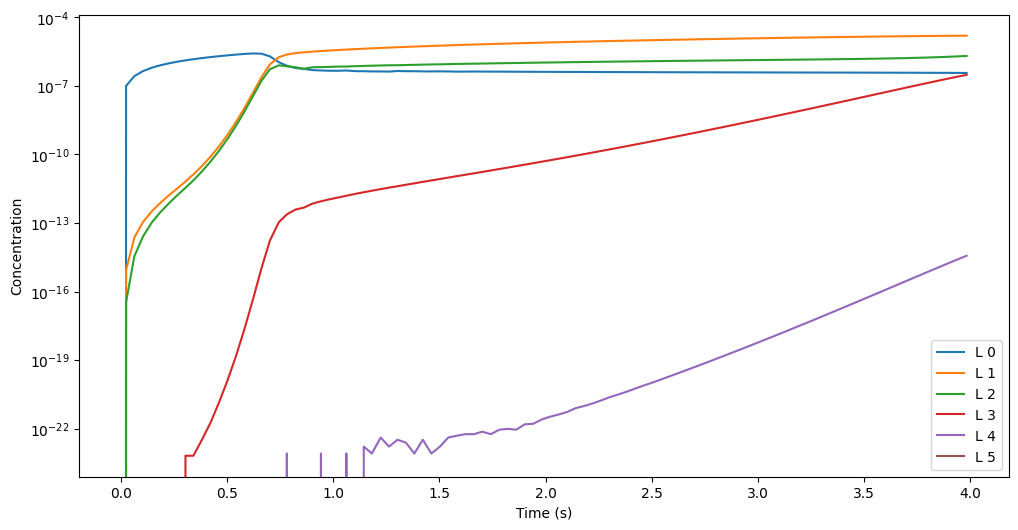

shape of time data:  (101,)
shape of conc data L (y result):  (2, 1)


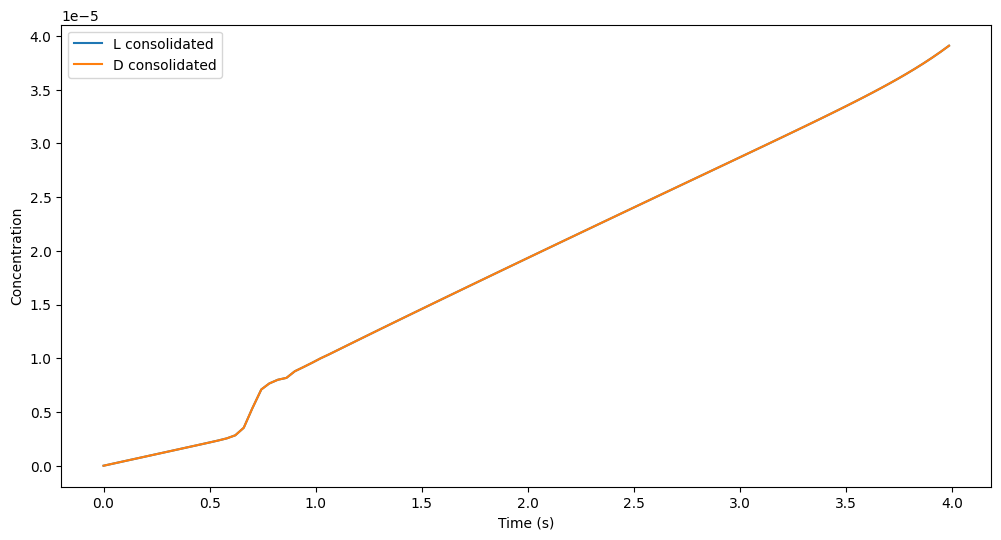

shape of time data:  (101,)
shape of conc data L (y result):  (2, 1)


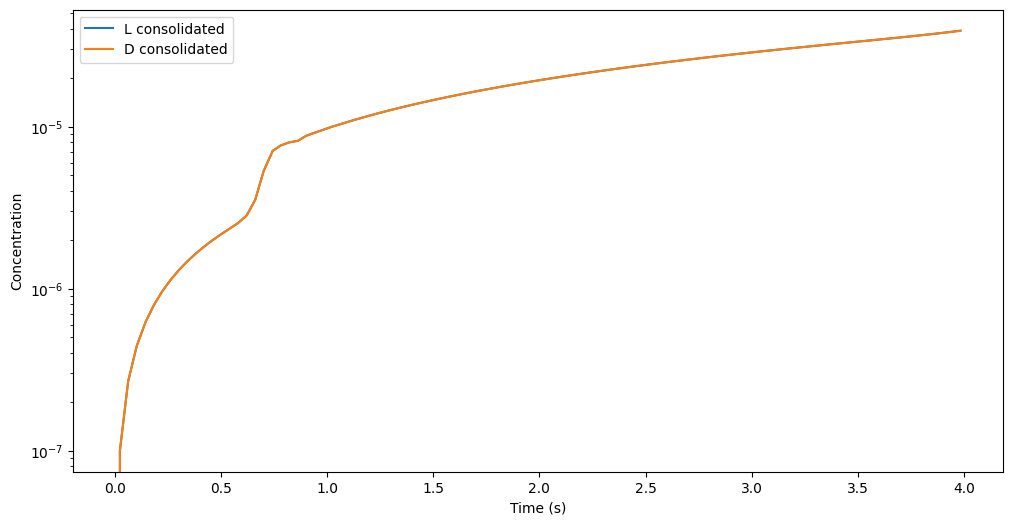

shape of time data:  (101,)
shape of conc data L (y result):  (2, 1)


/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/2097283166.py:522: RuntimeWarning: invalid value encountered in divide
  plt_data = plt_L_data / plt_D_data


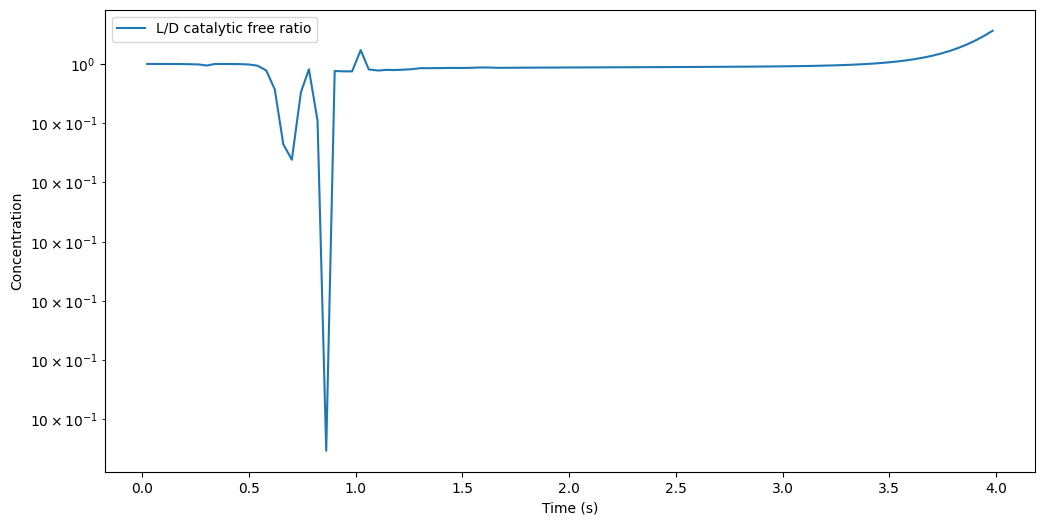

shape of time data:  (101,)
shape of conc data L (y result):  (2, 1)


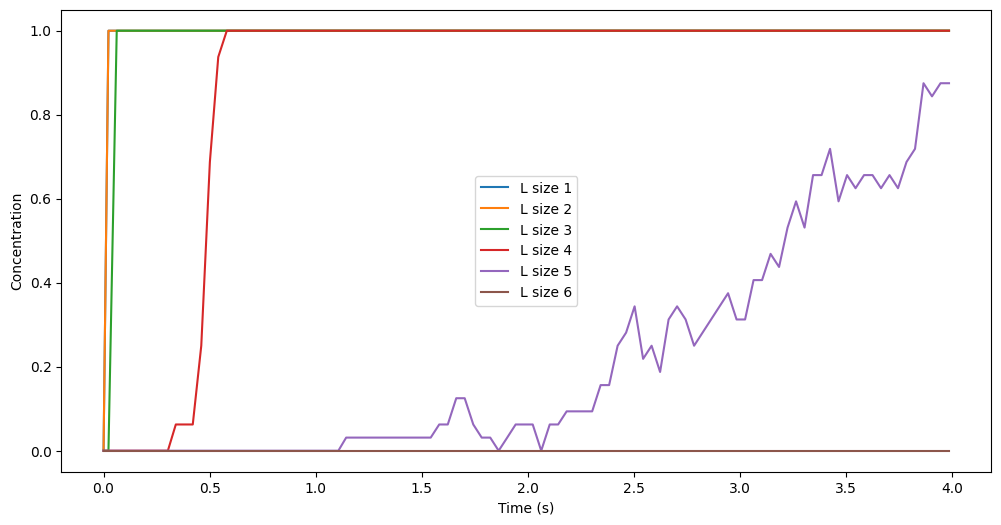

time_get_last:,  0.0 0.0
time_reacton_dyn:,  1.0 25.0
time_max_time_step:,  1.0 19.0
time_discretize:,  1.0 21.0
time_system_dev:,  1.0 35.0
time_other:,  0.0 0.0
 y result size:  6
y result free len:  6
Saving to file:  ./v44/save_file_v44_size_6_20260615_205723_progress.txt
Done saving (10, 101)
reduced save state:  True
y0 time dim:  (1,)
reduced conc time dim:  (10, 101)
y0 free t dim:  (2, 1)
y new free t dim:  (2, 1)
Time.  20260615_210103
........8max conc:  1.0023013742886928e-20 1e-20
#### NOTE: Extending model to:  7 7 7 7 7 7  #####
.. Progress: 20.0% - Time elapsed: 7.26 min - t: 8d - avg step: 19 - time factor: 47579
shape of conc data L:  (10, 201)
shape of conc data D:  (10, 201)
shape of time data:  (201,)
shape of conc data L (y result):  (2, 1)


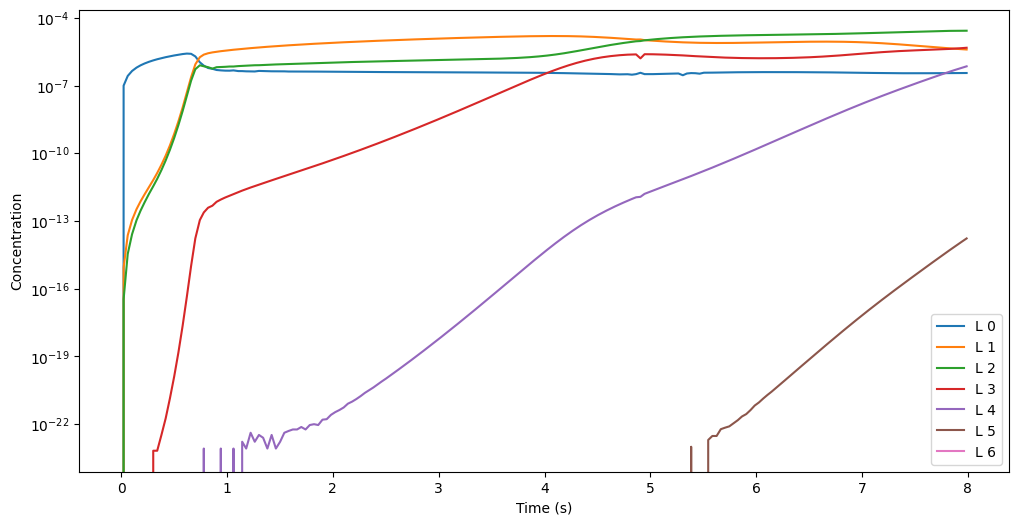

shape of time data:  (201,)
shape of conc data L (y result):  (2, 1)


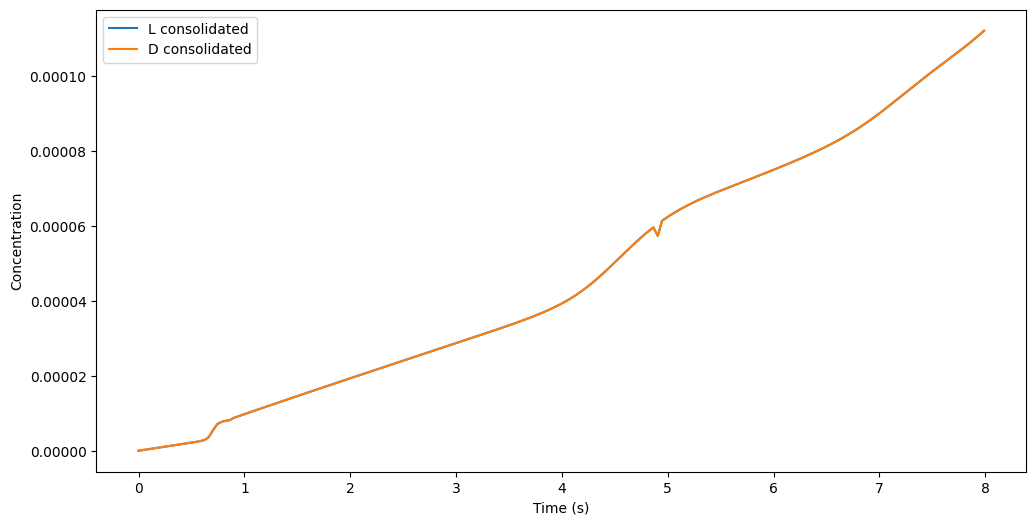

shape of time data:  (201,)
shape of conc data L (y result):  (2, 1)


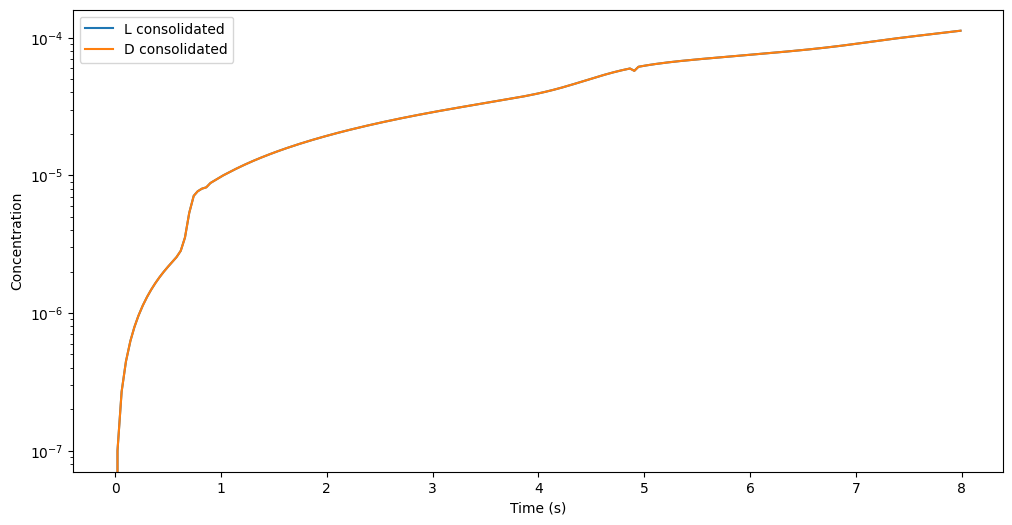

shape of time data:  (201,)
shape of conc data L (y result):  (2, 1)


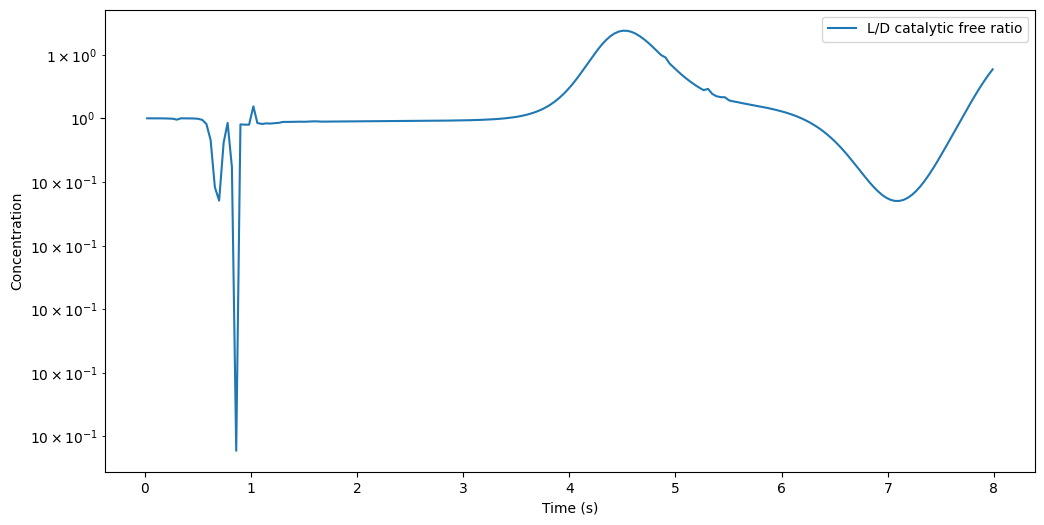

shape of time data:  (201,)
shape of conc data L (y result):  (2, 1)


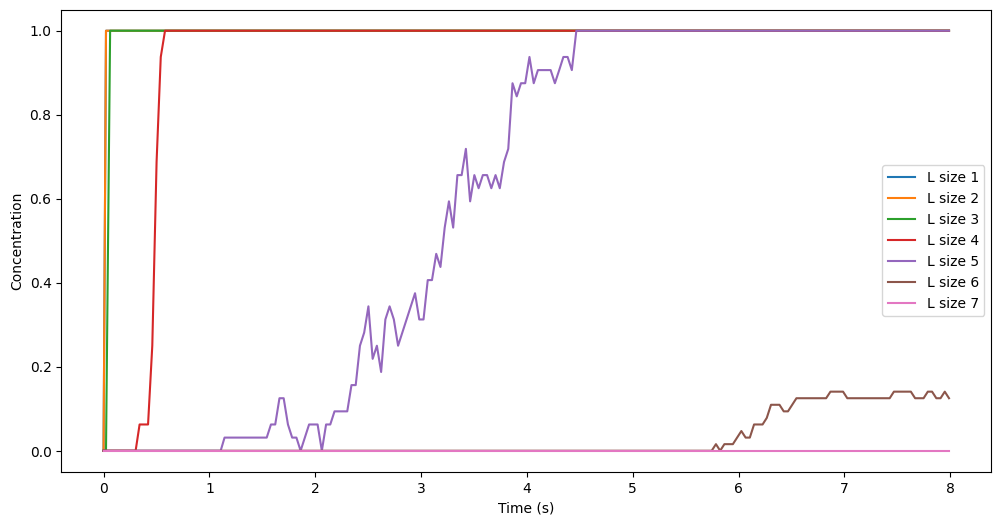

time_get_last:,  0.0 0.0
time_reacton_dyn:,  1.0 30.0
time_max_time_step:,  0.0 13.0
time_discretize:,  1.0 21.0
time_system_dev:,  1.0 36.0
time_other:,  0.0 0.0
 y result size:  7
y result free len:  7
Saving to file:  ./v44/save_file_v44_size_7_20260615_205723_progress.txt
Done saving (10, 201)
reduced save state:  True
y0 time dim:  (1,)
reduced conc time dim:  (10, 201)
y0 free t dim:  (2, 1)
y new free t dim:  (2, 1)
Time.  20260615_210439
........7max conc:  1.000806889138163e-20 1e-20
#### NOTE: Extending model to:  8 8 8 8 8 8  #####
.. Progress: 30.0% - Time elapsed: 21.72 min - t: 12d - avg step: 8 - time factor: 15914
shape of conc data L:  (10, 301)
shape of conc data D:  (10, 301)
shape of time data:  (301,)
shape of conc data L (y result):  (2, 1)


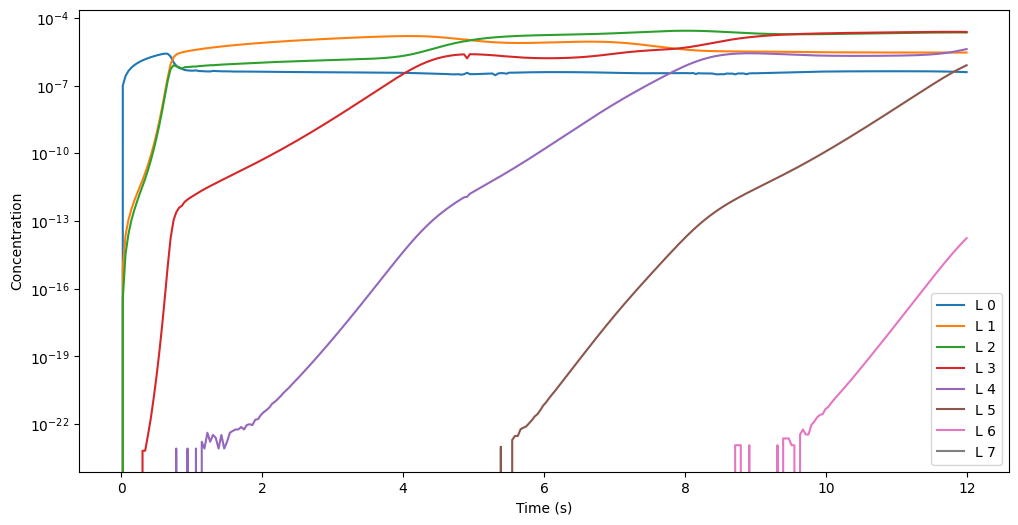

shape of time data:  (301,)
shape of conc data L (y result):  (2, 1)


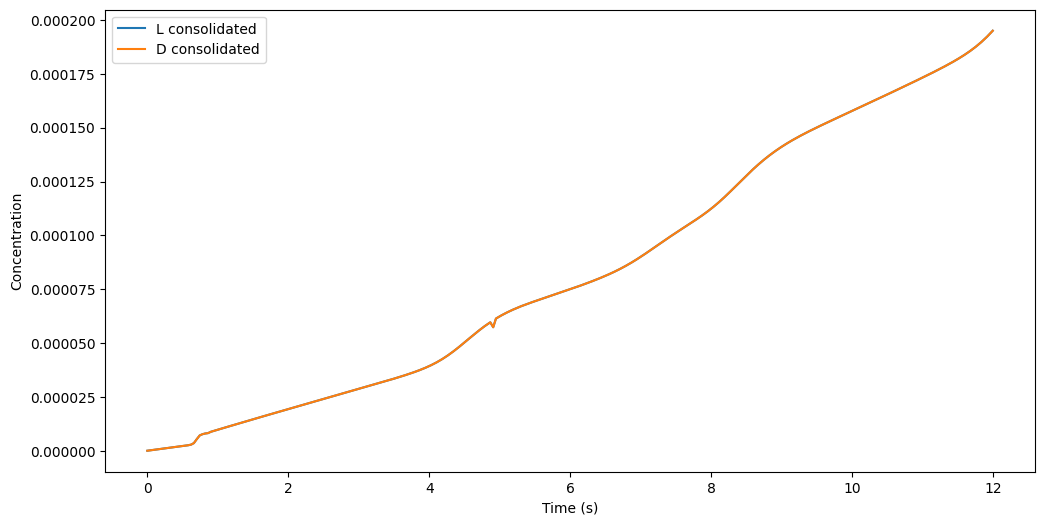

shape of time data:  (301,)
shape of conc data L (y result):  (2, 1)


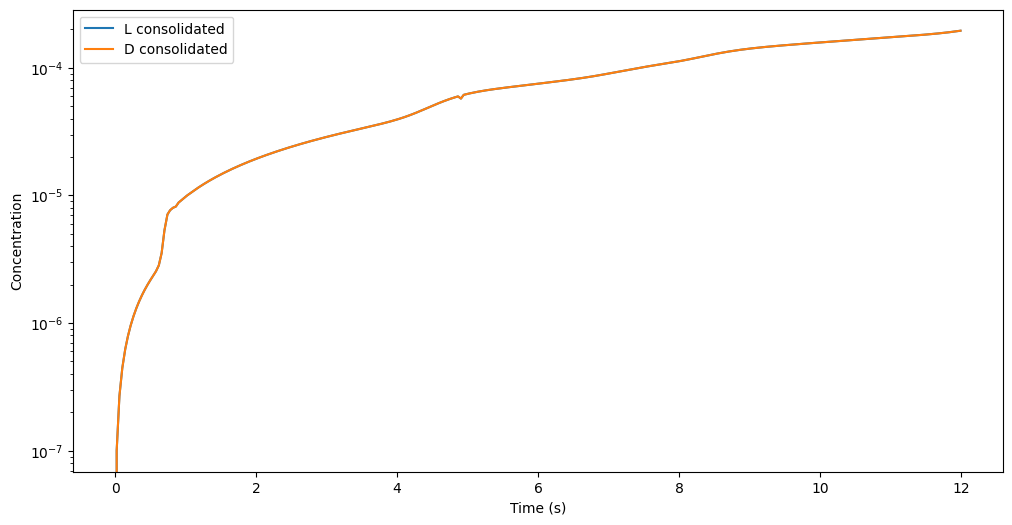

shape of time data:  (301,)
shape of conc data L (y result):  (2, 1)


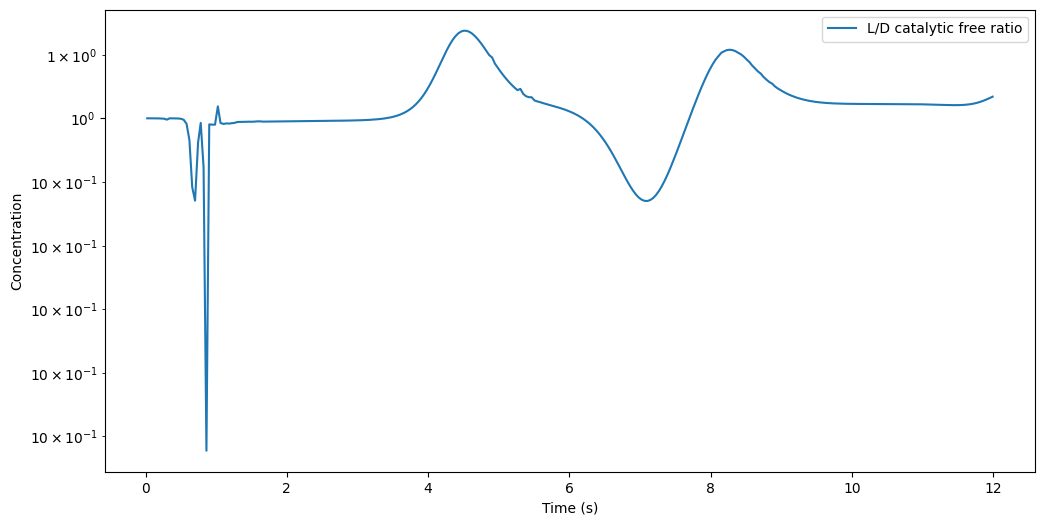

shape of time data:  (301,)
shape of conc data L (y result):  (2, 1)


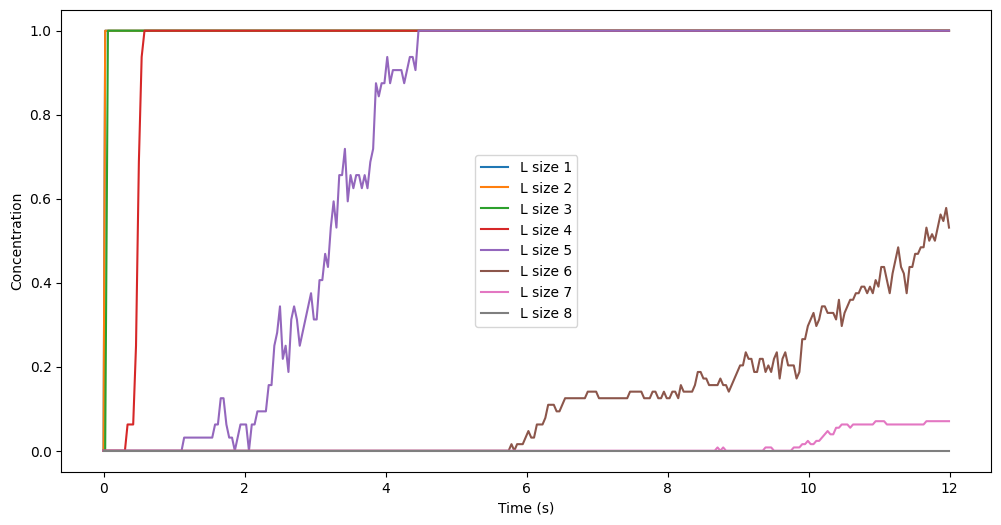

time_get_last:,  0.0 0.0
time_reacton_dyn:,  4.0 31.0
time_max_time_step:,  1.0 10.0
time_discretize:,  4.0 29.0
time_system_dev:,  4.0 30.0
time_other:,  0.0 0.0
 y result size:  8
y result free len:  8
Saving to file:  ./v44/save_file_v44_size_8_20260615_205723_progress.txt
Done saving (10, 301)
reduced save state:  True
y0 time dim:  (1,)
reduced conc time dim:  (10, 301)
y0 free t dim:  (2, 1)
y new free t dim:  (2, 1)
Time.  20260615_211907
.......... Progress: 40.0% - Time elapsed: 52.11 min - t: 16d - avg step: 6 - time factor: 6631
shape of conc data L:  (10, 401)
shape of conc data D:  (10, 401)
shape of time data:  (401,)
shape of conc data L (y result):  (2, 1)


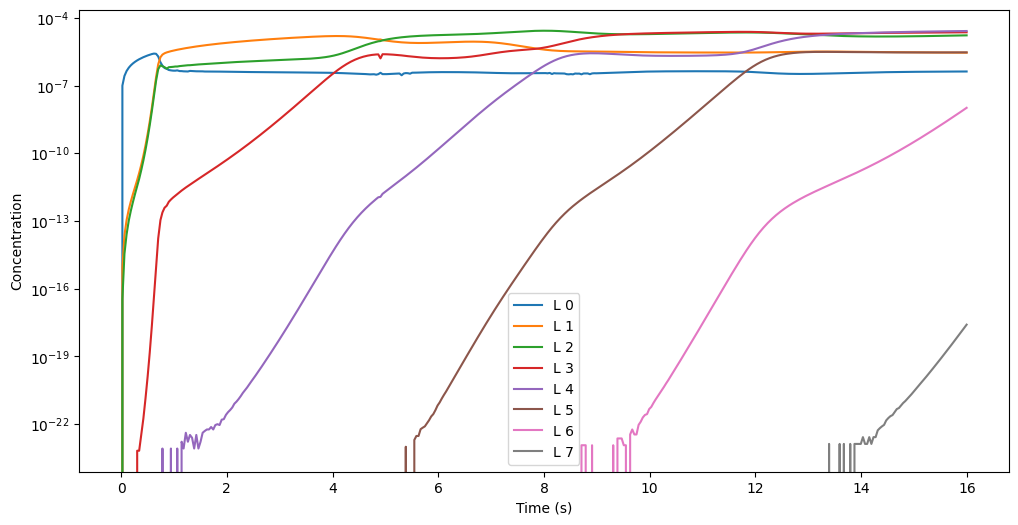

shape of time data:  (401,)
shape of conc data L (y result):  (2, 1)


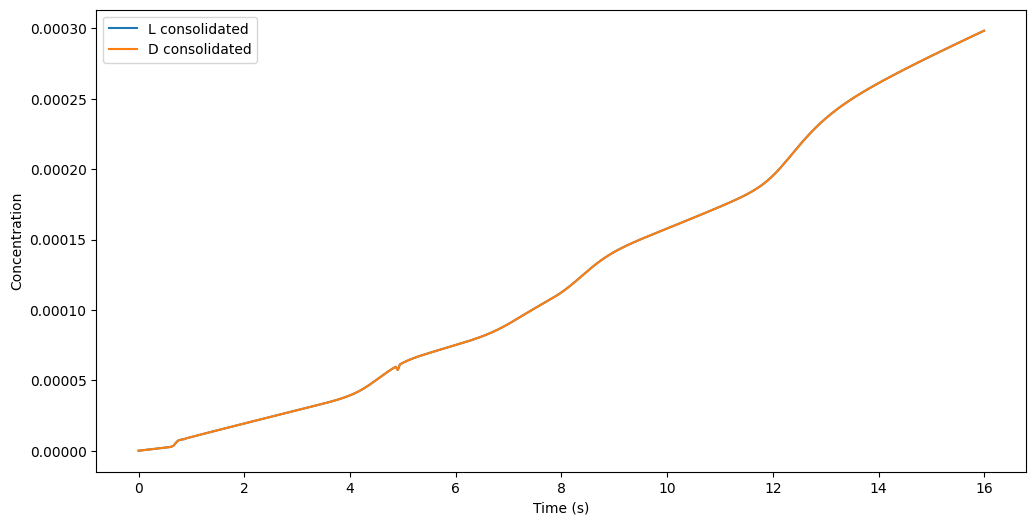

shape of time data:  (401,)
shape of conc data L (y result):  (2, 1)


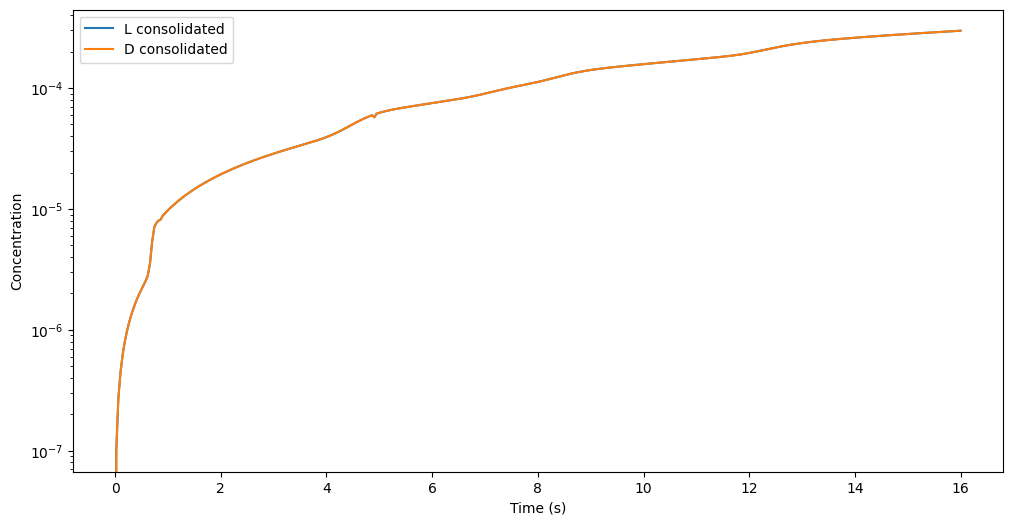

shape of time data:  (401,)
shape of conc data L (y result):  (2, 1)


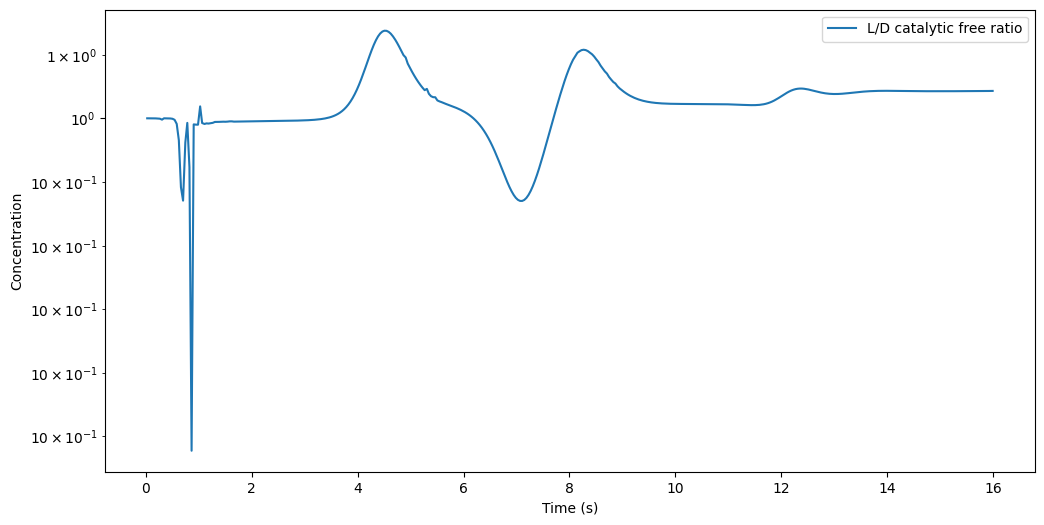

shape of time data:  (401,)
shape of conc data L (y result):  (2, 1)


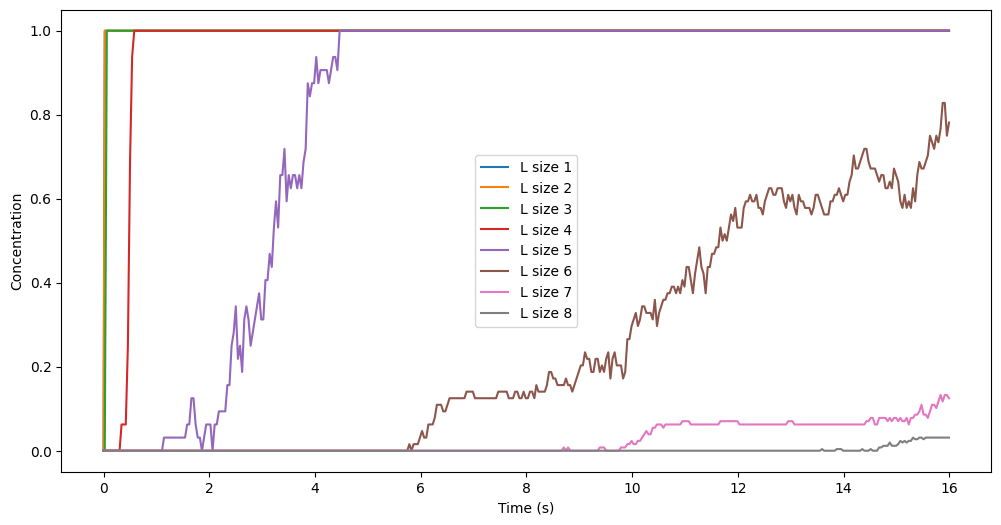

time_get_last:,  0.0 0.0
time_reacton_dyn:,  8.0 29.0
time_max_time_step:,  3.0 9.0
time_discretize:,  11.0 36.0
time_system_dev:,  7.0 26.0
time_other:,  0.0 0.0
 y result size:  8
y result free len:  8
Saving to file:  ./v44/save_file_v44_size_8_20260615_205723_progress.txt
Done saving (10, 401)
reduced save state:  True
y0 time dim:  (1,)
reduced conc time dim:  (10, 401)
y0 free t dim:  (2, 1)
y new free t dim:  (2, 1)
Time.  20260615_214931
. max conc:  1.001637158666235e-20 1e-20
#### NOTE: Extending model to:  9 9 9 9 9 9  #####
......... Progress: 50.0% - Time elapsed: 118.07 min - t: 20d - avg step: 6 - time factor: 2927
shape of conc data L:  (10, 501)
shape of conc data D:  (10, 501)
shape of time data:  (501,)
shape of conc data L (y result):  (2, 1)


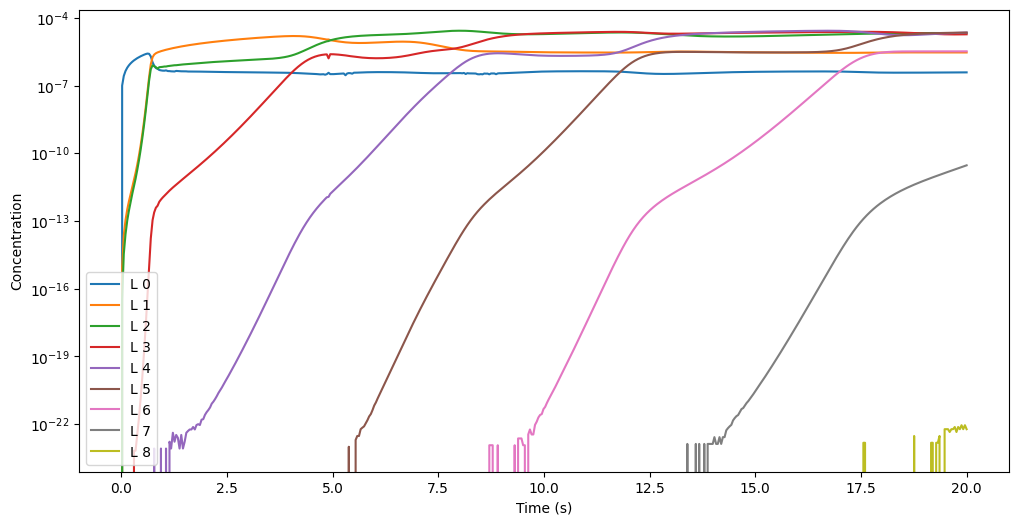

shape of time data:  (501,)
shape of conc data L (y result):  (2, 1)


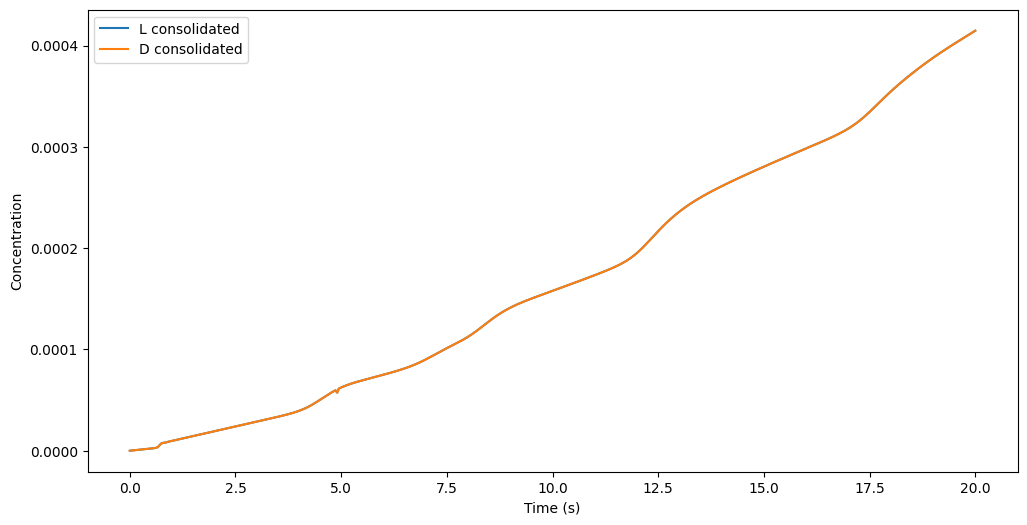

shape of time data:  (501,)
shape of conc data L (y result):  (2, 1)


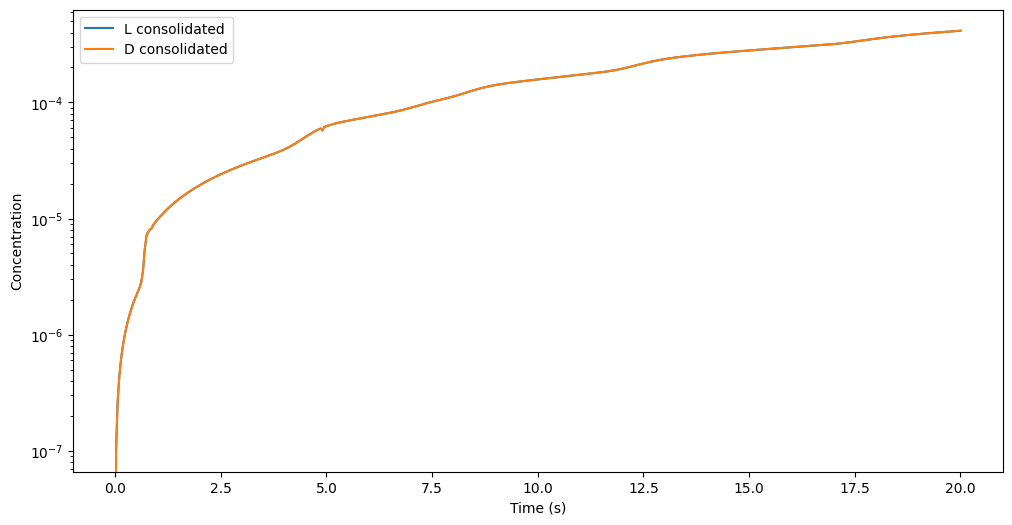

shape of time data:  (501,)
shape of conc data L (y result):  (2, 1)


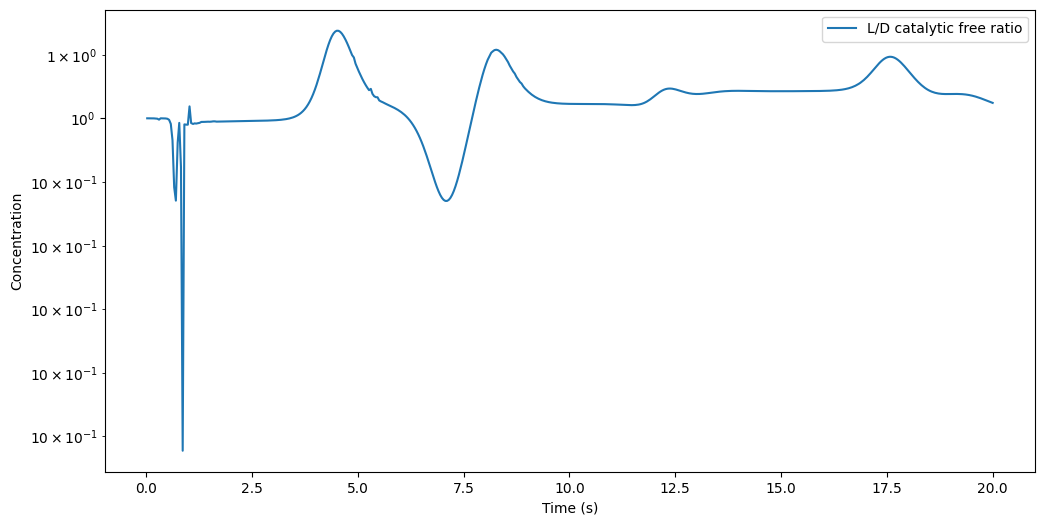

shape of time data:  (501,)
shape of conc data L (y result):  (2, 1)


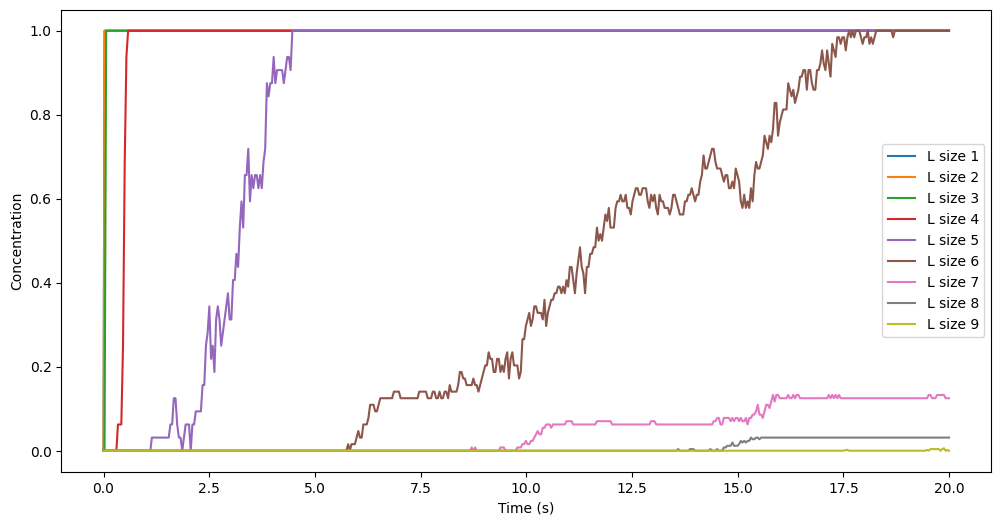

time_get_last:,  0.0 0.0
time_reacton_dyn:,  15.0 23.0
time_max_time_step:,  5.0 8.0
time_discretize:,  32.0 51.0
time_system_dev:,  12.0 18.0
time_other:,  0.0 0.0
 y result size:  9
y result free len:  9
Saving to file:  ./v44/save_file_v44_size_9_20260615_205723_progress.txt
Done saving (10, 501)
reduced save state:  True
y0 time dim:  (1,)
reduced conc time dim:  (10, 501)
y0 free t dim:  (2, 1)
y new free t dim:  (2, 1)
Time.  20260615_225528
.......... Progress: 60.0% - Time elapsed: 170.46 min - t: 24d - avg step: 9 - time factor: 2027
shape of conc data L:  (10, 600)
shape of conc data D:  (10, 600)
shape of time data:  (600,)
shape of conc data L (y result):  (2, 1)


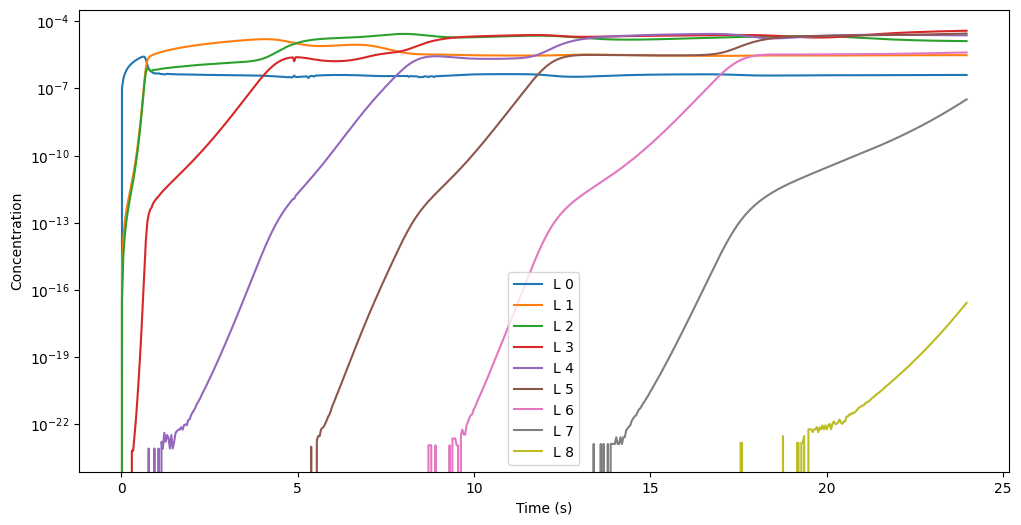

shape of time data:  (600,)
shape of conc data L (y result):  (2, 1)


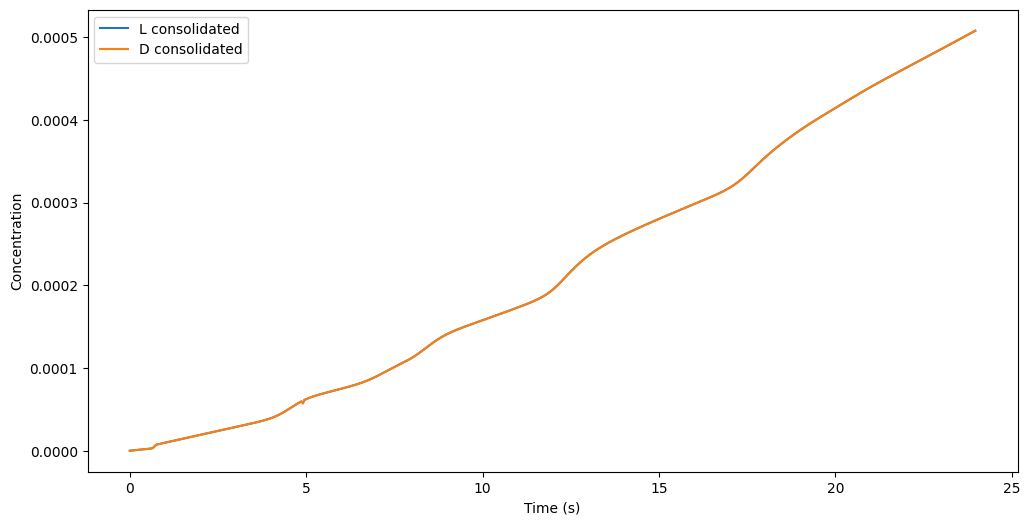

shape of time data:  (600,)
shape of conc data L (y result):  (2, 1)


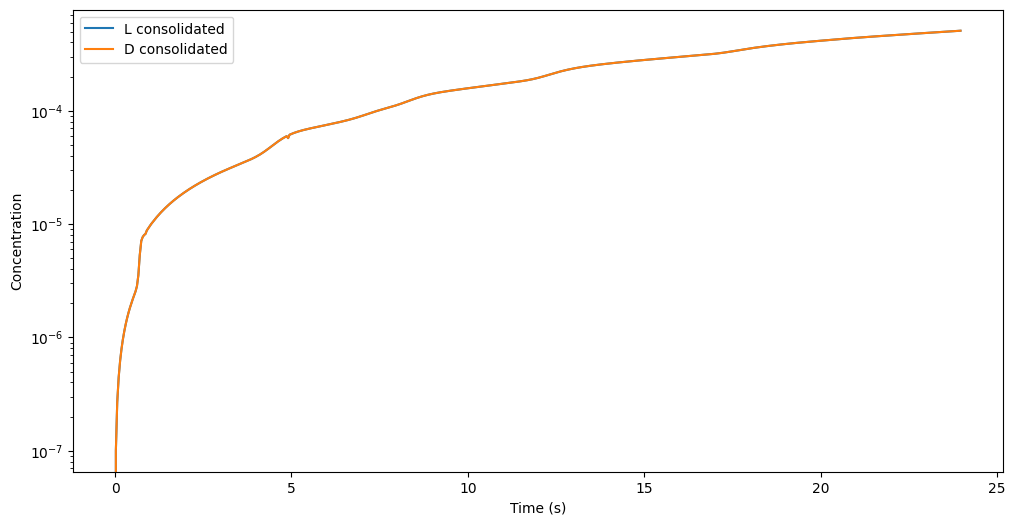

shape of time data:  (600,)
shape of conc data L (y result):  (2, 1)


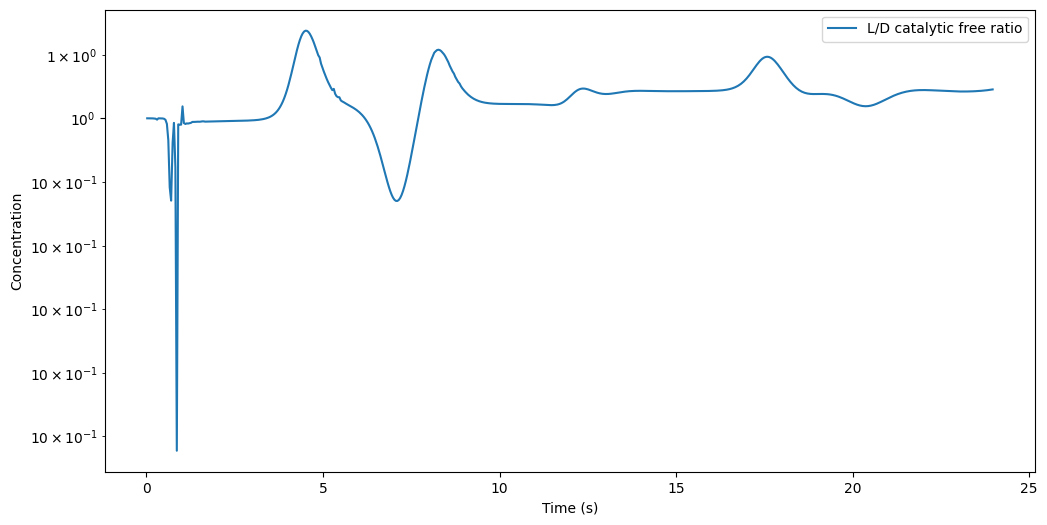

shape of time data:  (600,)
shape of conc data L (y result):  (2, 1)


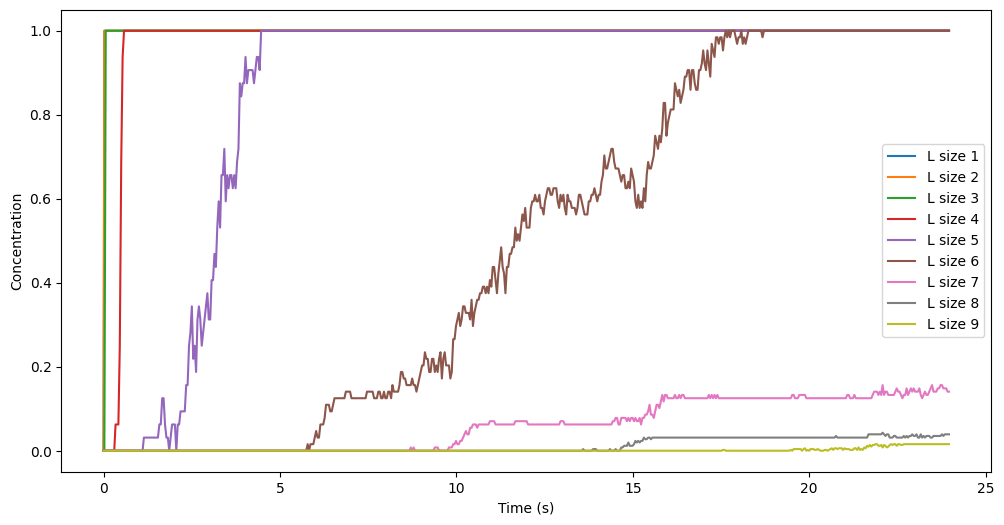

time_get_last:,  0.0 0.0
time_reacton_dyn:,  11.0 23.0
time_max_time_step:,  4.0 8.0
time_discretize:,  26.0 52.0
time_system_dev:,  9.0 18.0
time_other:,  0.0 0.0
 y result size:  9
y result free len:  9
Saving to file:  ./v44/save_file_v44_size_9_20260615_205723_progress.txt
Done saving (10, 600)
reduced save state:  True
y0 time dim:  (1,)
reduced conc time dim:  (10, 600)
y0 free t dim:  (2, 1)
y new free t dim:  (2, 1)
Time.  20260615_234751
8max conc:  1.0027995360055359e-20 1e-20
#### NOTE: Extending model to:  10 10 10 10 10 10  #####
.......... Progress: 70.0% - Time elapsed: 446.41 min - t: 28d - avg step: 5 - time factor: 774
shape of conc data L:  (10, 700)
shape of conc data D:  (10, 700)
shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


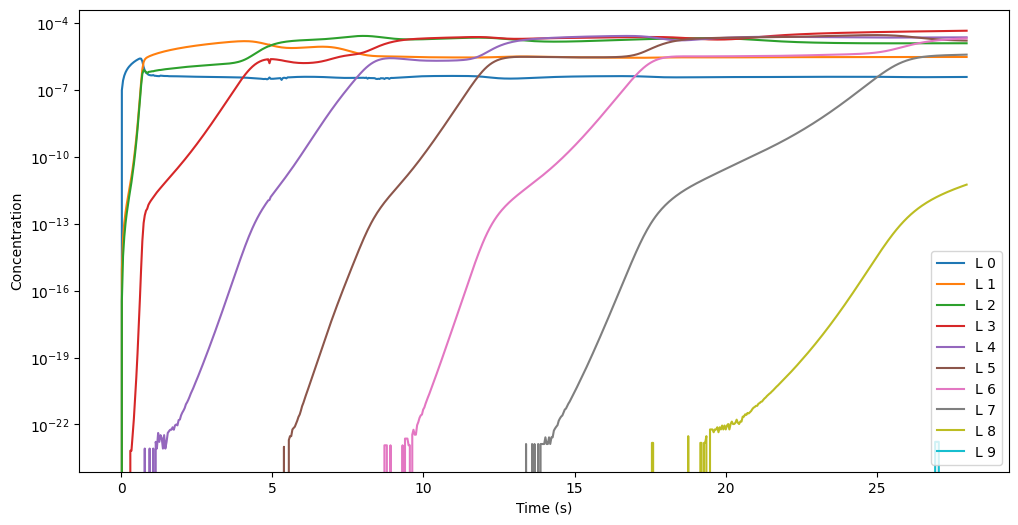

shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


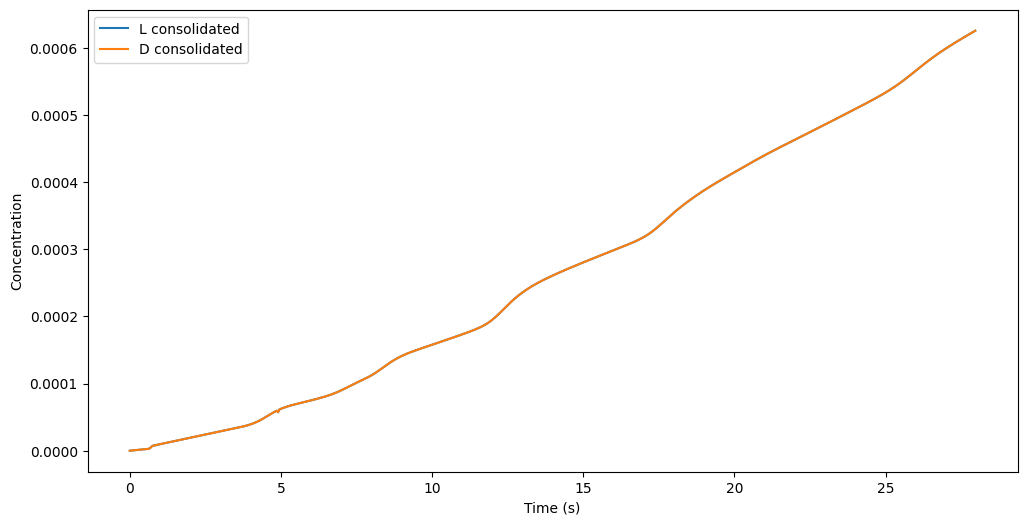

shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


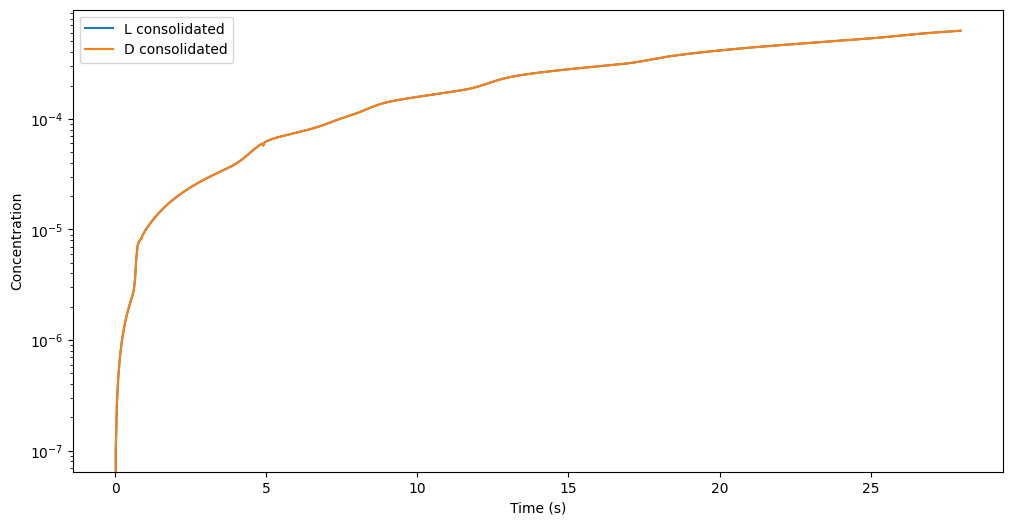

shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


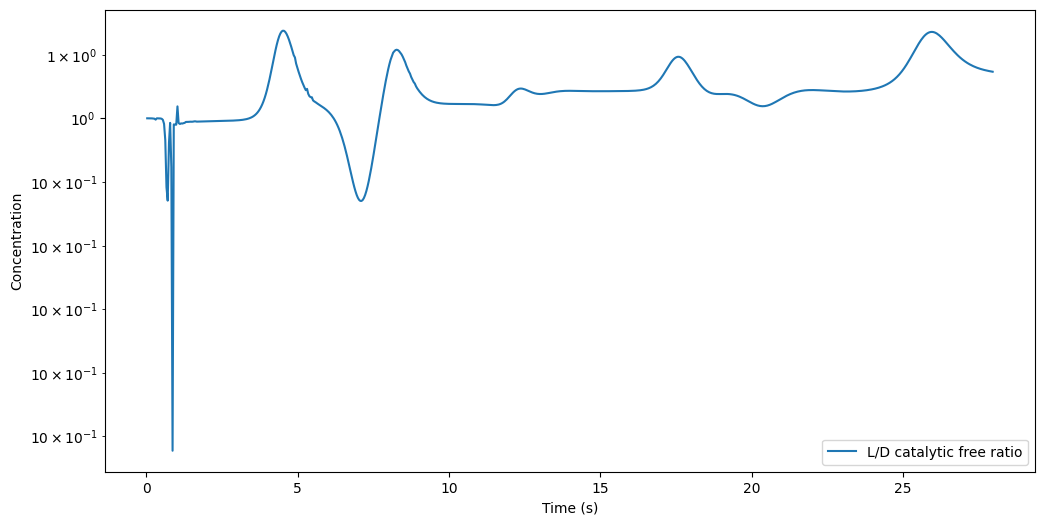

shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


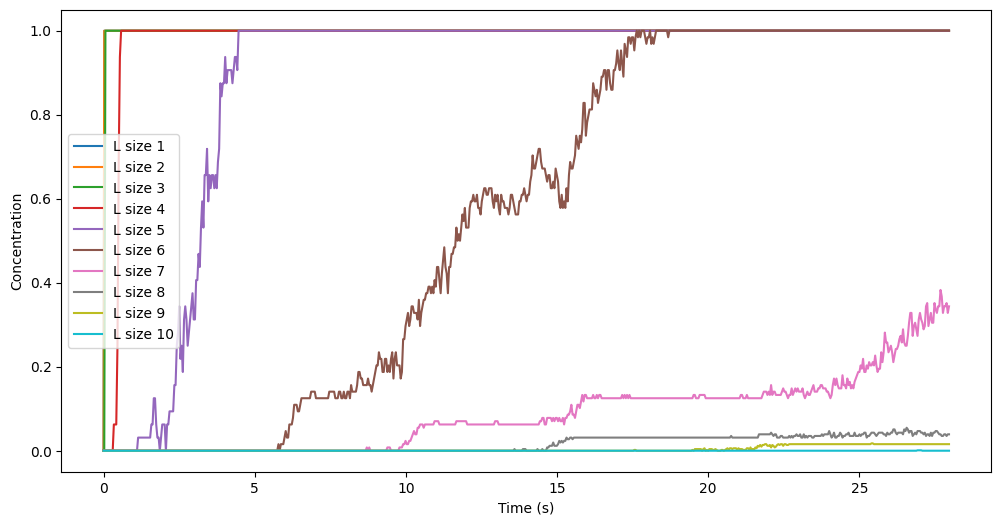

Free cat ratio:     nan
Hairpin cat ratio:  nan
0
shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/3228906392.py:264: RuntimeWarning: invalid value encountered in scalar divide
  cat_free_ratio    = y0.L.cat_free[-1]/y0.D.cat_free[-1]
/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/3228906392.py:265: RuntimeWarning: invalid value encountered in scalar divide
  cat_hairpin_ratio = y0.L.cat_hairpin[-1]/y0.D.cat_hairpin[-1]
/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/2097283166.py:492: RuntimeWarning: divide by zero encountered in divide
  plt_data = plt_L_data / plt_D_data
/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/2097283166.py:492: RuntimeWarning: invalid value encountered in divide
  plt_data = plt_L_data / plt_D_data


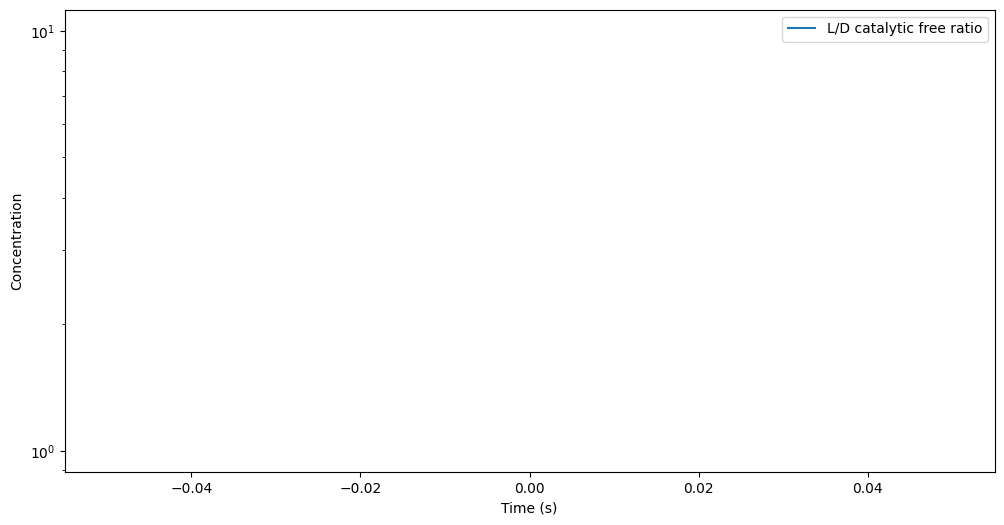

0
shape of time data:  (700,)
shape of conc data L (y result):  (2, 1)


/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/2097283166.py:504: RuntimeWarning: invalid value encountered in divide
  plt_data = plt_L_data / plt_D_data


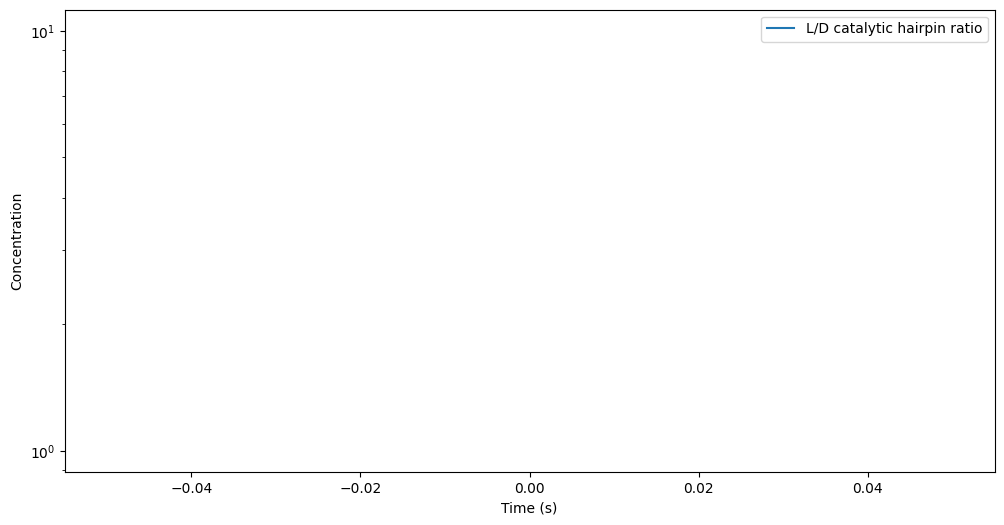

shape of time data:  (1,)
shape of conc data L (y result):  (2, 1)


/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/2097283166.py:558: RuntimeWarning: invalid value encountered in divide
  plt.plot(plt_x_data, plt_data_L_cat / plt_data_D_cat, label=f'Cat trail L/D ratio (free)')


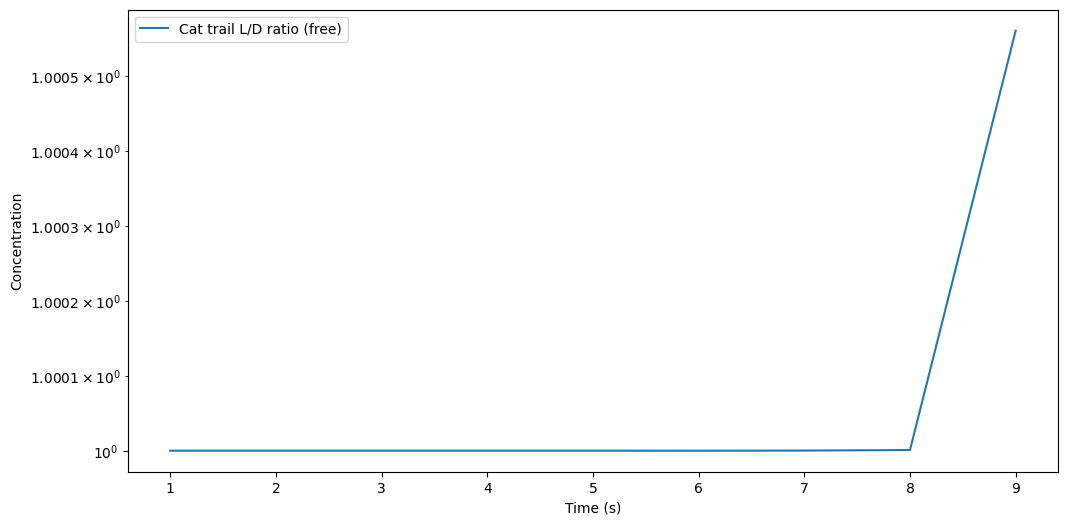

/var/folders/fw/khtlmjqj7dngtnws6zhj43500000gn/T/ipykernel_54645/2097283166.py:572: RuntimeWarning: invalid value encountered in divide
  plt.plot(plt_x_data, plt_data_L_cat / plt_data_D_cat, label=f'Cat trail L/D ratio (hairpin)')


shape of time data:  (1,)
shape of conc data L (y result):  (2, 1)


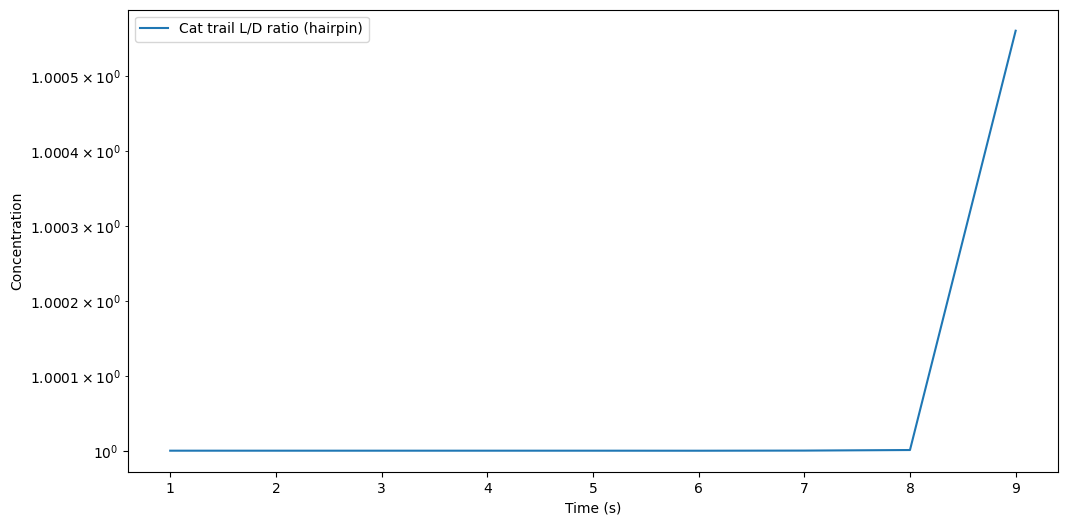

(array([[1.00000000e+00, 2.00000000e+00, 3.00000000e+00, 4.00000000e+00,
        5.00000000e+00, 6.00000000e+00, 7.00000000e+00, 8.00000000e+00,
        9.00000000e+00, 1.00000000e+01],
       [1.94728991e-07, 2.19764538e-07, 2.79323628e-07, 3.40755812e-07,
        4.04885498e-07, 4.77167834e-07, 5.20736753e-07, 6.25641806e-13,
        1.19954020e-19, 0.00000000e+00],
       [1.94728991e-07, 2.19764575e-07, 2.79323655e-07, 3.40755829e-07,
        4.04885508e-07, 4.77167840e-07, 5.20736757e-07, 6.25641810e-13,
        1.19990552e-19, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [1.94728990e-07, 2.19764537e-07, 2.79323627e-07, 3.40755810e-07,
  

In [ ]:
p_use = ModelControlParameters(size             = 3, 
                           output_steps         = 1000,
                           model_max_t          = 40 * 24 * 3600, 
                           max_time_step        = 500, 
                           max_time_step_change = 0.5,
                           auto_extend          = True,
                           auto_extend_to       = 10,
                           save_progress        = True,
                           reduced_save_state   = True
                          )


k_use = ReactionConstants(p = p_use,                 
                          catalytic_hairpin = 1,
                          k_hairpin_cat     = 1e7,
                          catalytic_free    = 0,
                          k_free_cat        = 0
)


model  = EvolutionModel(p   = p_use,
                        k   = k_use)

if False:
    model.load(file_name = "save_file_v40_size_8_20241219_071633_progress.txt", folder = "./v40/")
    model.solve_ctd(add_time = 1 * 24 * 3600)
else:
    model.solve()
    

In [ ]:
#model.solve_ctd(add_time = 40 * 24 * 3600)

In [ ]:
# Saving small models (size 4)

In [ ]:
# Leaning L
# Saving to file:  ./v40/save_file_v40_size_4_20241210_081519_100.0.txt
# Saving to file:  ./v40/save_file_v40_size_4_20241210_083722_100.0.txt
# 

In [ ]:
# Leaning D
# 

In [ ]:
#model.solve_ctd(add_time = 200 * 24 * 3600)

In [ ]:
#model.solve_ctd(add_time = 200 * 24 * 3600)

In [ ]:
#model.solve_ctd(add_time = 400 * 24 * 3600)

In [ ]:
#model.solve_ctd(add_time = 500 * 24 * 3600)

In [ ]:
#model.solve_ctd(add_time = 500 * 24 * 3600)


model.solve_ctd(add_time = 500 * 24 * 3600)


model.solve_ctd(add_time = 500 * 24 * 3600)

model.solve_ctd(add_time = 500 * 24 * 3600)